In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers datasets scikit-learn matplotlib seaborn

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import BertTokenizer, BertModel

In [ ]:
dataset = load_dataset("glue", "sst2")

train_data = dataset["train"]

# Take small subset (IMPORTANT for speed)
samples = [train_data[i]["sentence"] for i in range(200)]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = BertModel.from_pretrained(
    "bert-base-uncased",
    output_hidden_states=True
).to(device)

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

model.eval()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
all_activations = []

for text in samples:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    hidden_states = outputs.hidden_states  # 13 layers (embeddings + 12 layers)

    # Collect CLS token activations
    cls_acts = [layer[0, 0, :].cpu().numpy() for layer in hidden_states]

    all_activations.append(cls_acts)

all_activations = np.array(all_activations)

In [ ]:
# Variance across samples
variance = np.var(all_activations, axis=0)  # shape: (layers, neurons)

In [ ]:
roles = []

for layer_var in variance:
    low = np.percentile(layer_var, 33)
    high = np.percentile(layer_var, 66)

    layer_roles = []

    for v in layer_var:
        if v > high:
            layer_roles.append("Fragile")
        elif v < low:
            layer_roles.append("Core")
        else:
            layer_roles.append("Collaborative")

    roles.append(layer_roles)

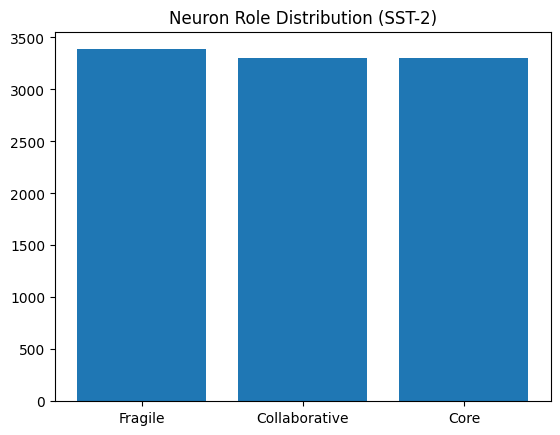

In [ ]:
role_counts = {"Fragile": 0, "Collaborative": 0, "Core": 0}

for layer in roles:
    for r in layer:
        role_counts[r] += 1

plt.bar(role_counts.keys(), role_counts.values())
plt.title("Neuron Role Distribution (SST-2)")
plt.show()

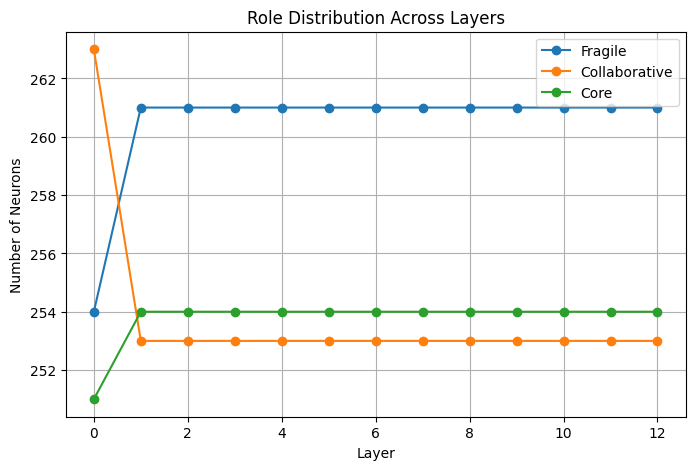

In [ ]:
fragile_counts = []
collab_counts = []
core_counts = []

for layer in roles:
    fragile_counts.append(layer.count("Fragile"))
    collab_counts.append(layer.count("Collaborative"))
    core_counts.append(layer.count("Core"))

layers = list(range(len(roles)))

plt.figure(figsize=(8,5))
plt.plot(layers, fragile_counts, label="Fragile", marker='o')
plt.plot(layers, collab_counts, label="Collaborative", marker='o')
plt.plot(layers, core_counts, label="Core", marker='o')

plt.xlabel("Layer")
plt.ylabel("Number of Neurons")
plt.title("Role Distribution Across Layers")
plt.legend()
plt.grid()
plt.show()

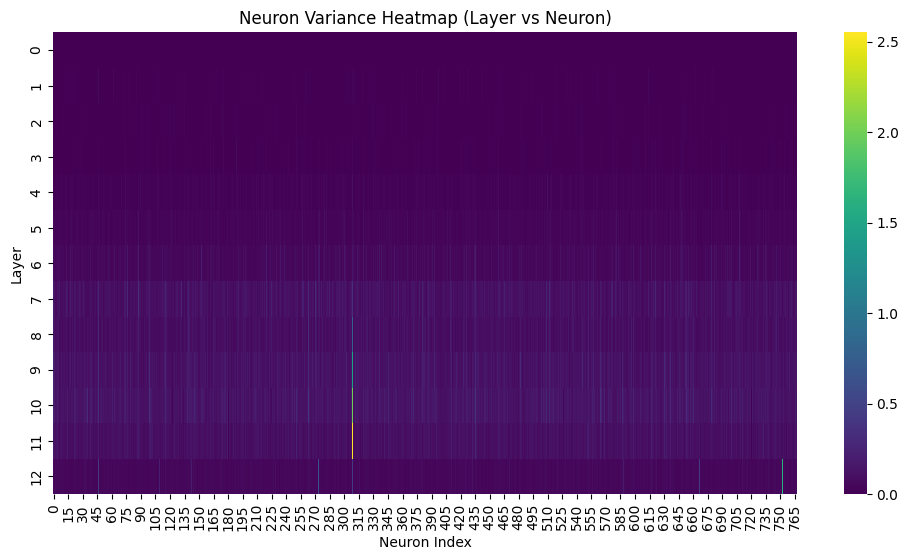

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(variance, cmap="viridis")

plt.title("Neuron Variance Heatmap (Layer vs Neuron)")
plt.xlabel("Neuron Index")
plt.ylabel("Layer")
plt.show()

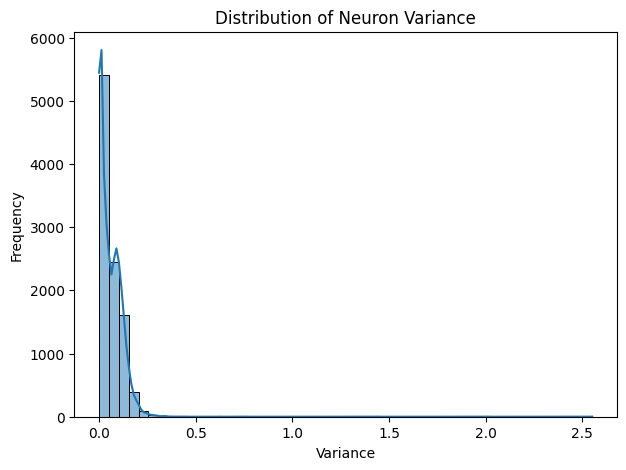

In [ ]:
all_var = variance.flatten()

plt.figure(figsize=(7,5))
sns.histplot(all_var, bins=50, kde=True)

plt.title("Distribution of Neuron Variance")
plt.xlabel("Variance")
plt.ylabel("Frequency")
plt.show()

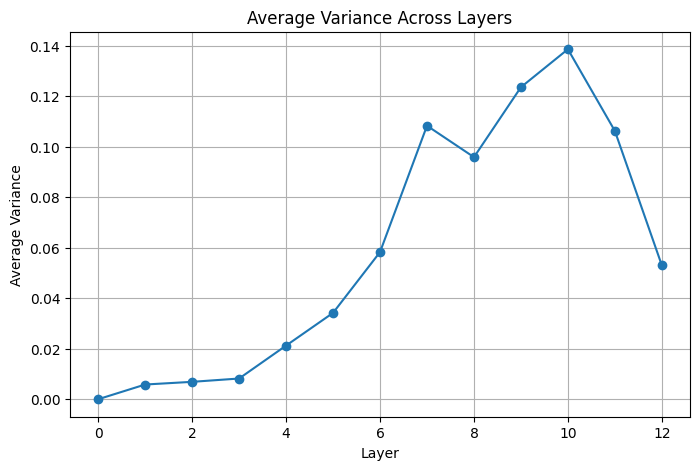

In [ ]:
avg_var_per_layer = np.mean(variance, axis=1)

plt.figure(figsize=(8,5))
plt.plot(avg_var_per_layer, marker='o')

plt.title("Average Variance Across Layers")
plt.xlabel("Layer")
plt.ylabel("Average Variance")
plt.grid()
plt.show()

In [ ]:
import random

random_roles = []

for layer in roles:
    random_layer = [random.choice(["Fragile", "Collaborative", "Core"]) for _ in layer]
    random_roles.append(random_layer)

random_counts = {"Fragile": 0, "Collaborative": 0, "Core": 0}

for layer in random_roles:
    for r in layer:
        random_counts[r] += 1

print("Actual:", role_counts)
print("Random:", random_counts)

Actual: {'Fragile': 3386, 'Collaborative': 3299, 'Core': 3299}
Random: {'Fragile': 3352, 'Collaborative': 3343, 'Core': 3289}


In [ ]:
print("Average Variance per Layer:\n", avg_var_per_layer)

print("\nMax Variance Layer:", np.argmax(avg_var_per_layer))
print("Min Variance Layer:", np.argmin(avg_var_per_layer))

Average Variance per Layer:
 [4.2846220e-13 5.8258022e-03 6.8899752e-03 8.2055666e-03 2.1250516e-02
 3.4217421e-02 5.8310539e-02 1.0837257e-01 9.5917523e-02 1.2364280e-01
 1.3868921e-01 1.0630386e-01 5.3039968e-02]

Max Variance Layer: 10
Min Variance Layer: 0


In [ ]:
mean_act = np.mean(all_activations, axis=0)  # shape: (layers, neurons)

In [ ]:
mean_roles = []

for layer_mean in mean_act:
    low = np.percentile(layer_mean, 33)
    high = np.percentile(layer_mean, 66)

    layer_roles = []

    for v in layer_mean:
        if v > high:
            layer_roles.append("High")
        elif v < low:
            layer_roles.append("Low")
        else:
            layer_roles.append("Medium")

    mean_roles.append(layer_roles)

In [ ]:
# Variance counts (already done)
var_counts = {"Fragile": 0, "Collaborative": 0, "Core": 0}

for layer in roles:
    for r in layer:
        var_counts[r] += 1


# Mean counts
mean_counts = {"High": 0, "Medium": 0, "Low": 0}

for layer in mean_roles:
    for r in layer:
        mean_counts[r] += 1


print("Variance-based roles:", var_counts)
print("Mean-based roles:", mean_counts)

Variance-based roles: {'Fragile': 3386, 'Collaborative': 3299, 'Core': 3299}
Mean-based roles: {'High': 3393, 'Medium': 3289, 'Low': 3302}


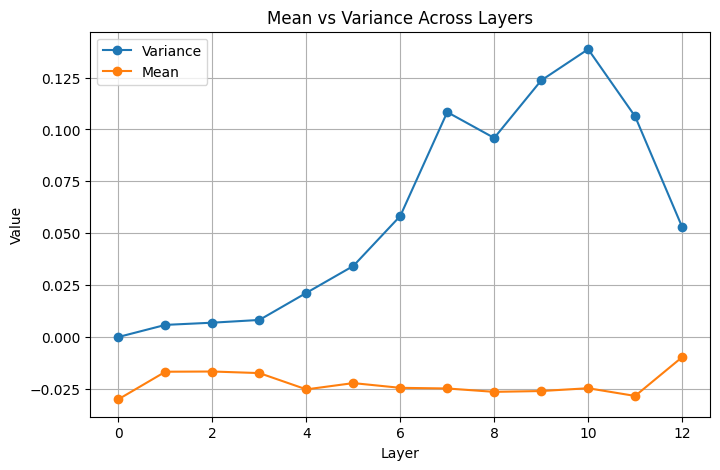

In [ ]:
var_layer_avg = np.mean(variance, axis=1)
mean_layer_avg = np.mean(mean_act, axis=1)

plt.figure(figsize=(8,5))

plt.plot(var_layer_avg, label="Variance", marker='o')
plt.plot(mean_layer_avg, label="Mean", marker='o')

plt.title("Mean vs Variance Across Layers")
plt.xlabel("Layer")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()

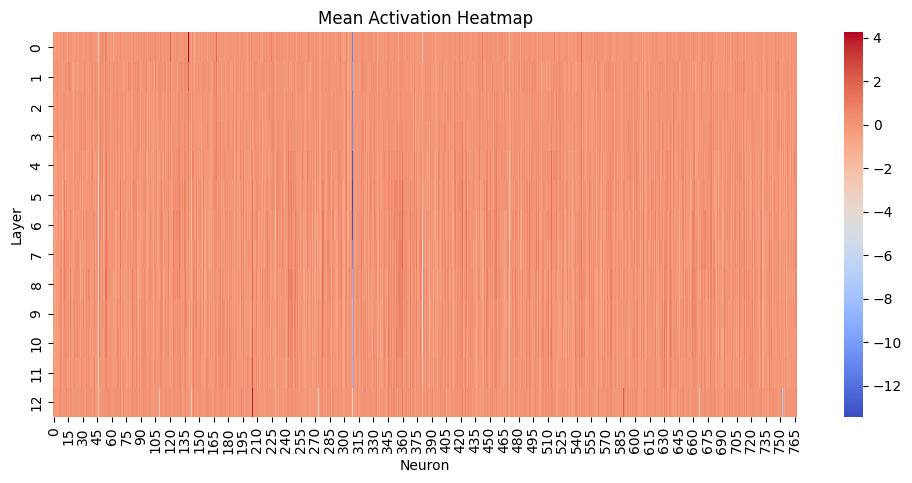

In [ ]:
plt.figure(figsize=(12,5))
sns.heatmap(mean_act, cmap="coolwarm")
plt.title("Mean Activation Heatmap")
plt.xlabel("Neuron")
plt.ylabel("Layer")
plt.show()

In [ ]:
sample_sizes = [100, 300, 500]

In [ ]:
def compute_variance_for_samples(samples):
    activations = []

    for text in samples:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        hidden_states = outputs.hidden_states
        cls_acts = [layer[0, 0, :].cpu().numpy() for layer in hidden_states]

        activations.append(cls_acts)

    activations = np.array(activations)
    variance = np.var(activations, axis=0)

    avg_var_per_layer = np.mean(variance, axis=1)

    return avg_var_per_layer

In [ ]:
results = {}

for size in sample_sizes:
    subset = [train_data[i]["sentence"] for i in range(size)]
    results[size] = compute_variance_for_samples(subset)

In [ ]:
for size in sample_sizes:
    print(f"Max variance layer ({size} samples):", np.argmax(results[size]))

Max variance layer (100 samples): 10
Max variance layer (300 samples): 10
Max variance layer (500 samples): 10


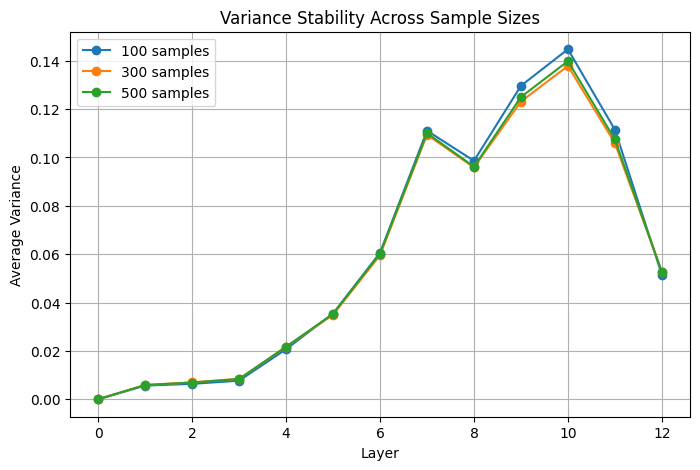

In [ ]:
plt.figure(figsize=(8,5))

for size in sample_sizes:
    plt.plot(results[size], label=f"{size} samples", marker='o')

plt.title("Variance Stability Across Sample Sizes")
plt.xlabel("Layer")
plt.ylabel("Average Variance")
plt.legend()
plt.grid()
plt.show()

##We observe consistent variance distributions across multiple sample sizes, demonstrating that neuron behavior is stable and not dependent on data sampling, thereby validating the robustness of variance as a behavioral metric

In [ ]:
def get_mean_pool_activations(samples):
    activations = []

    for text in samples:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        hidden_states = outputs.hidden_states

        # Mean pooling across tokens
        mean_acts = [layer[0].mean(dim=0).cpu().numpy() for layer in hidden_states]

        activations.append(mean_acts)

    activations = np.array(activations)
    variance = np.var(activations, axis=0)

    avg_var_per_layer = np.mean(variance, axis=1)

    return avg_var_per_layer

In [ ]:
# Already computed earlier
cls_variance = np.mean(variance, axis=1)

# Compute mean pooling variance
mean_pool_variance = get_mean_pool_activations(samples)

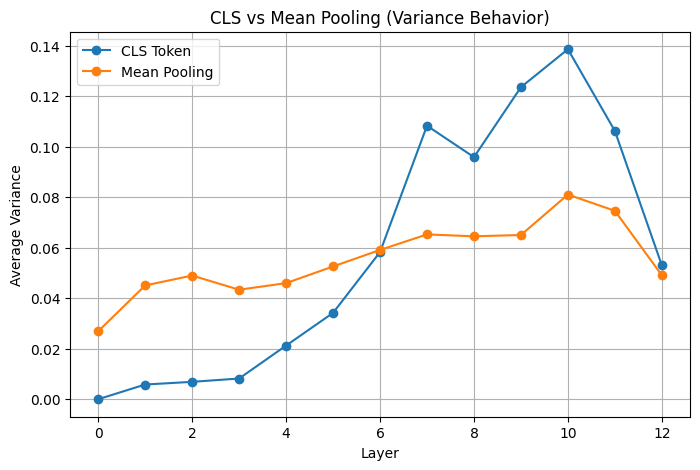

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(cls_variance, label="CLS Token", marker='o')
plt.plot(mean_pool_variance, label="Mean Pooling", marker='o')

plt.title("CLS vs Mean Pooling (Variance Behavior)")
plt.xlabel("Layer")
plt.ylabel("Average Variance")
plt.legend()
plt.grid()
plt.show()

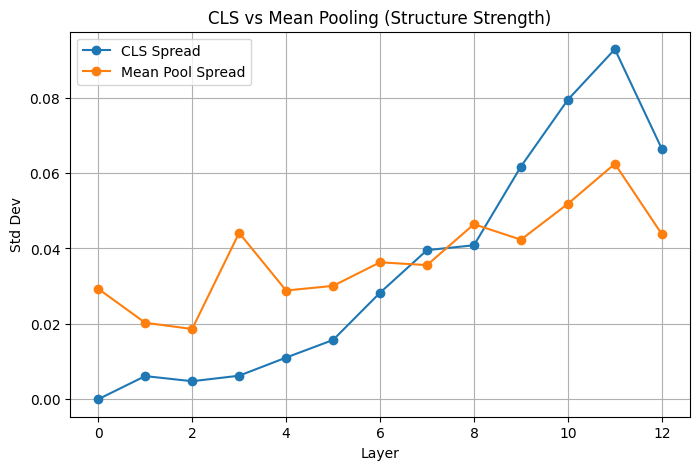

In [ ]:
cls_spread = np.std(variance, axis=1)
mean_pool_spread = []

# recompute full variance for mean pooling (not just avg)
mean_pool_full = []

for text in samples:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    hidden_states = outputs.hidden_states
    mean_acts = [layer[0].mean(dim=0).cpu().numpy() for layer in hidden_states]

    mean_pool_full.append(mean_acts)

mean_pool_full = np.array(mean_pool_full)
mean_pool_variance_full = np.var(mean_pool_full, axis=0)

mean_pool_spread = np.std(mean_pool_variance_full, axis=1)

plt.figure(figsize=(8,5))
plt.plot(cls_spread, label="CLS Spread", marker='o')
plt.plot(mean_pool_spread, label="Mean Pool Spread", marker='o')

plt.title("CLS vs Mean Pooling (Structure Strength)")
plt.xlabel("Layer")
plt.ylabel("Std Dev")
plt.legend()
plt.grid()
plt.show()

##We demonstrate that CLS-based representations produce significantly more structured and discriminative neuron behavior compared to mean pooling, particularly in deeper layers, validating CLS as a more suitable representation for neuron-level analysis

In [ ]:
mnli = load_dataset("glue", "mnli")

mnli_samples = [mnli["train"][i]["premise"] + " " + mnli["train"][i]["hypothesis"] for i in range(300)]

mnli/train-00000-of-00001.parquet:   0%|          | 0.00/52.2M [00:00<?, ?B/s]

mnli/validation_matched-00000-of-00001.p(…):   0%|          | 0.00/1.21M [00:00<?, ?B/s]

mnli/validation_mismatched-00000-of-0000(…):   0%|          | 0.00/1.25M [00:00<?, ?B/s]

mnli/test_matched-00000-of-00001.parquet:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

mnli/test_mismatched-00000-of-00001.parq(…):   0%|          | 0.00/1.26M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/392702 [00:00<?, ? examples/s]

Generating validation_matched split:   0%|          | 0/9815 [00:00<?, ? examples/s]

Generating validation_mismatched split:   0%|          | 0/9832 [00:00<?, ? examples/s]

Generating test_matched split:   0%|          | 0/9796 [00:00<?, ? examples/s]

Generating test_mismatched split:   0%|          | 0/9847 [00:00<?, ? examples/s]

In [ ]:
mnli_variance = compute_variance_for_samples(mnli_samples)

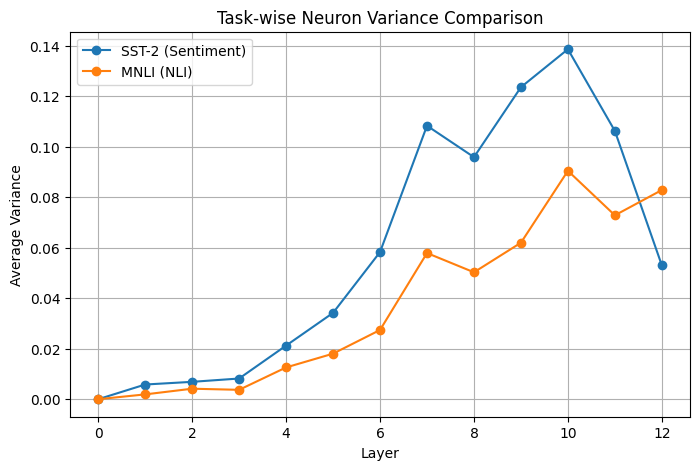

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(cls_variance, label="SST-2 (Sentiment)", marker='o')
plt.plot(mnli_variance, label="MNLI (NLI)", marker='o')

plt.title("Task-wise Neuron Variance Comparison")
plt.xlabel("Layer")
plt.ylabel("Average Variance")
plt.legend()
plt.grid()
plt.show()

In [ ]:
mnli_activations = []

for text in mnli_samples:
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(device)

    with torch.no_grad():  # 🔥 IMPORTANT FIX
        outputs = model(**inputs)

    hidden_states = outputs.hidden_states

    # CLS token extraction
    cls_acts = [layer[0, 0, :].cpu().numpy() for layer in hidden_states]

    mnli_activations.append(cls_acts)

# Convert to numpy
mnli_activations = np.array(mnli_activations)

# Compute variance
mnli_variance_full = np.var(mnli_activations, axis=0)

In [ ]:
print("SST roles layers:", len(roles))
print("MNLI roles layers:", len(mnli_roles))

if len(mnli_roles) > 0:
    print("Neurons in layer 0 (SST):", len(roles[0]))
    print("Neurons in layer 0 (MNLI):", len(mnli_roles[0]))

SST roles layers: 13
MNLI roles layers: 0


In [ ]:
print("MNLI sample size:", len(mnli_samples))
print(mnli_samples[:2])

MNLI sample size: 300
['Conceptually cream skimming has two basic dimensions - product and geography. Product and geography are what make cream skimming work. ', 'you know during the season and i guess at at your level uh you lose them to the next level if if they decide to recall the the parent team the Braves decide to call to recall a guy from triple A then a double A guy goes up to replace him and a single A guy goes up to replace him You lose the things to the following level if the people recall.']


In [ ]:
def get_roles(samples):
    activations = []

    for i, text in enumerate(samples):
        try:
            inputs = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=64   # 🔥 IMPORTANT (prevents long MNLI issues)
            ).to(device)

            with torch.no_grad():
                outputs = model(**inputs)

            hidden_states = outputs.hidden_states
            cls_acts = [layer[0, 0, :].cpu().numpy() for layer in hidden_states]

            activations.append(cls_acts)

        except Exception as e:
            print(f"Error at sample {i}: {e}")
            continue

    if len(activations) == 0:
        print("❌ No activations collected!")
        return []

    activations = np.array(activations)
    variance = np.var(activations, axis=0)

    roles = []
    for layer_var in variance:
        low = np.percentile(layer_var, 33)
        high = np.percentile(layer_var, 66)

        layer_roles = []
        for v in layer_var:
            if v > high:
                layer_roles.append("Fragile")
            elif v < low:
                layer_roles.append("Core")
            else:
                layer_roles.append("Collaborative")

        roles.append(layer_roles)

    return roles

In [ ]:
roles = get_roles(samples)
mnli_roles = get_roles(mnli_samples)

In [ ]:
print("SST layers:", len(roles))
print("MNLI layers:", len(mnli_roles))

SST layers: 13
MNLI layers: 13


In [ ]:
changes = 0
total = 0

for l in range(len(roles)):
    for n in range(len(roles[l])):
        if roles[l][n] != mnli_roles[l][n]:
            changes += 1
        total += 1

print("Role Change %:", (changes / total) * 100)

Role Change %: 50.36057692307693


##We found that around 50% of neurons change their roles across tasks, indicating that neuron behavior is not static but adapts depending on the task, revealing a balance between stable and dynamic representations

In [ ]:
from collections import defaultdict

transition_counts = defaultdict(int)

for l in range(len(roles)):
    for n in range(len(roles[l])):
        old_role = roles[l][n]
        new_role = mnli_roles[l][n]

        transition_counts[(old_role, new_role)] += 1

# Print results
for k, v in transition_counts.items():
    print(f"{k[0]} → {k[1]} : {v}")

Core → Fragile : 459
Fragile → Fragile : 1843
Core → Collaborative : 1024
Core → Core : 1816
Fragile → Collaborative : 991
Collaborative → Fragile : 1084
Collaborative → Collaborative : 1297
Fragile → Core : 552
Collaborative → Core : 918


In [ ]:
import pandas as pd

states = ["Fragile", "Collaborative", "Core"]

matrix = pd.DataFrame(0, index=states, columns=states)

for (old, new), count in transition_counts.items():
    matrix.loc[old, new] = count

print(matrix)

               Fragile  Collaborative  Core
Fragile           1843            991   552
Collaborative     1084           1297   918
Core               459           1024  1816


In [ ]:
prob_matrix = matrix.div(matrix.sum(axis=1), axis=0)

print(prob_matrix)

                Fragile  Collaborative      Core
Fragile        0.544300       0.292676  0.163024
Collaborative  0.328584       0.393149  0.278266
Core           0.139133       0.310397  0.550470


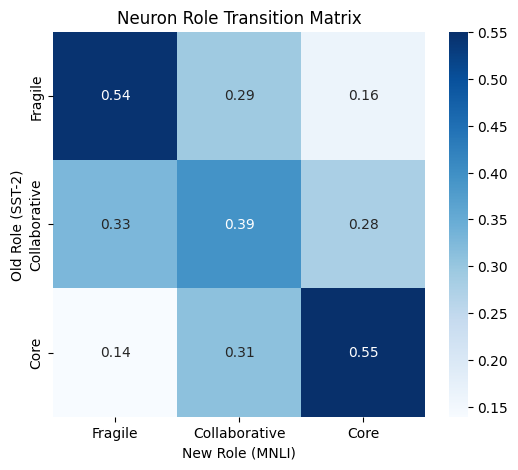

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(prob_matrix, annot=True, cmap="Blues", fmt=".2f")

plt.title("Neuron Role Transition Matrix")
plt.xlabel("New Role (MNLI)")
plt.ylabel("Old Role (SST-2)")
plt.show()

##Neuron roles exhibit partial stability, with a significant proportion maintaining their functional identity across tasks
#Fragile → Collaborative = 0.29
#Fragile → Core = 0.16

#Nearly 45% change

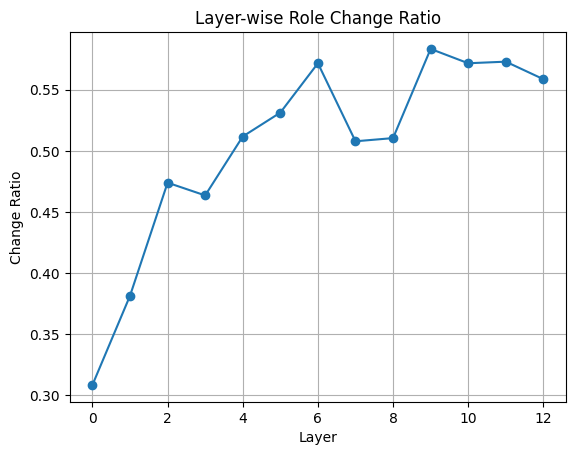

In [ ]:
layer_transition = []

for l in range(len(roles)):
    transitions = {"same": 0, "change": 0}

    for n in range(len(roles[l])):
        if roles[l][n] == mnli_roles[l][n]:
            transitions["same"] += 1
        else:
            transitions["change"] += 1

    total = transitions["same"] + transitions["change"]
    layer_transition.append(transitions["change"] / total)

import matplotlib.pyplot as plt

plt.plot(layer_transition, marker='o')
plt.title("Layer-wise Role Change Ratio")
plt.xlabel("Layer")
plt.ylabel("Change Ratio")
plt.grid()
plt.show()

In [ ]:
stability_scores = []

for l in range(len(roles)):
    for n in range(len(roles[l])):
        if roles[l][n] == mnli_roles[l][n]:
            stability_scores.append(1)
        else:
            stability_scores.append(0)

stability_score = sum(stability_scores) / len(stability_scores)
print("Global Stability:", stability_score)

Global Stability: 0.4963942307692308


In [ ]:
always_core = 0
always_fragile = 0

for l in range(len(roles)):
    for n in range(len(roles[l])):
        if roles[l][n] == "Core" and mnli_roles[l][n] == "Core":
            always_core += 1
        if roles[l][n] == "Fragile" and mnli_roles[l][n] == "Fragile":
            always_fragile += 1

print("Always Core:", always_core)
print("Always Fragile:", always_fragile)

Always Core: 1816
Always Fragile: 1843


In [ ]:
total_neurons = len(roles) * len(roles[0])

print("Always Core %:", (always_core / total_neurons) * 100)
print("Always Fragile %:", (always_fragile / total_neurons) * 100)

Always Core %: 18.189102564102562
Always Fragile %: 18.459535256410255


In [ ]:
fully_stable = 0

for l in range(len(roles)):
    for n in range(len(roles[l])):
        if roles[l][n] == mnli_roles[l][n]:
            fully_stable += 1

print("Fully Stable Neurons %:", (fully_stable / total_neurons) * 100)

Fully Stable Neurons %: 49.63942307692308


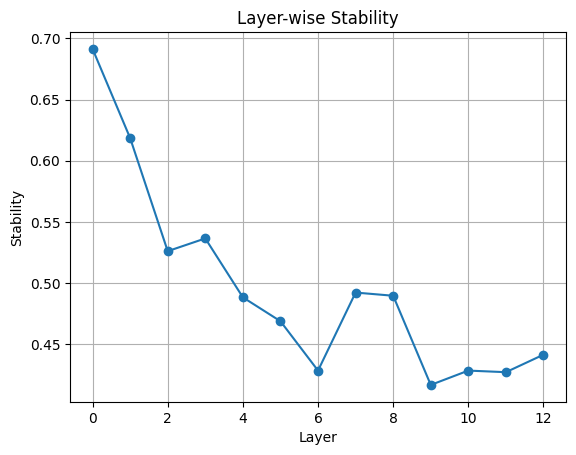

In [ ]:
layer_stability = []

for l in range(len(roles)):
    same = 0
    total = len(roles[l])

    for n in range(total):
        if roles[l][n] == mnli_roles[l][n]:
            same += 1

    layer_stability.append(same / total)

plt.plot(layer_stability, marker='o')
plt.title("Layer-wise Stability")
plt.xlabel("Layer")
plt.ylabel("Stability")
plt.grid()
plt.show()

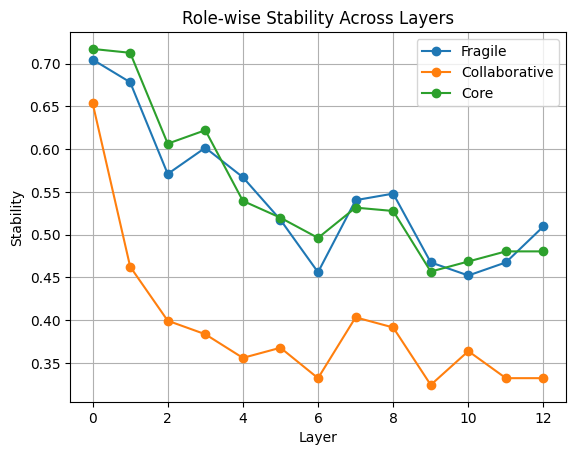

In [ ]:
role_stability = {
    "Fragile": [],
    "Collaborative": [],
    "Core": []
}

for l in range(len(roles)):
    counts = {"Fragile": [0,0], "Collaborative": [0,0], "Core": [0,0]}

    for n in range(len(roles[l])):
        r1 = roles[l][n]
        r2 = mnli_roles[l][n]

        counts[r1][1] += 1
        if r1 == r2:
            counts[r1][0] += 1

    for key in counts:
        if counts[key][1] > 0:
            role_stability[key].append(counts[key][0] / counts[key][1])
        else:
            role_stability[key].append(0)

for key in role_stability:
    plt.plot(role_stability[key], label=key, marker='o')

plt.legend()
plt.title("Role-wise Stability Across Layers")
plt.xlabel("Layer")
plt.ylabel("Stability")
plt.grid()
plt.show()

In [ ]:
consistency_scores = []

for l in range(len(roles)):
    for n in range(len(roles[l])):
        consistency_scores.append(1 if roles[l][n] == mnli_roles[l][n] else 0)

consistency_scores = np.array(consistency_scores)

print("Mean Consistency:", np.mean(consistency_scores))
print("Std Consistency:", np.std(consistency_scores))

Mean Consistency: 0.4963942307692308
Std Consistency: 0.4999869982592091


In [ ]:
always_change = 0

for l in range(len(roles)):
    for n in range(len(roles[l])):
        if roles[l][n] != mnli_roles[l][n]:
            always_change += 1

print("Always Changing %:", (always_change / total_neurons) * 100)

Always Changing %: 50.36057692307693


In [ ]:
labels = []

for l in range(len(roles)):
    for n in range(len(roles[l])):
        if roles[l][n] == mnli_roles[l][n]:
            labels.append(0)  # Stable
        else:
            labels.append(1)  # Change

labels = np.array(labels)
print("Total samples:", len(labels))

Total samples: 9984


In [ ]:
features = []

# Use variance + mean (you already computed these earlier)
for l in range(len(variance)):
    for n in range(len(variance[l])):
        v = variance[l][n]
        m = mean_act[l][n]

        features.append([v, m])

features = np.array(features)

print("Feature shape:", features.shape)

Feature shape: (9984, 2)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

model_clf = RandomForestClassifier(n_estimators=100)
model_clf.fit(X_train, y_train)

y_pred = model_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5498247371056585
              precision    recall  f1-score   support

           0       0.57      0.51      0.54      1019
           1       0.54      0.59      0.56       978

    accuracy                           0.55      1997
   macro avg       0.55      0.55      0.55      1997
weighted avg       0.55      0.55      0.55      1997



In [ ]:
importances = model_clf.feature_importances_

print("Variance importance:", importances[0])
print("Mean importance:", importances[1])

Variance importance: 0.514107720751654
Mean importance: 0.4858922792483461


In [ ]:
features = []

for l in range(len(variance)):
    layer_var = variance[l]

    # Rank of variance within layer
    ranks = np.argsort(np.argsort(layer_var))

    for n in range(len(layer_var)):
        v = variance[l][n]            # variance
        m = mean_act[l][n]           # mean
        r = ranks[n]                 # rank within layer
        layer_id = l                 # layer index

        features.append([v, m, r, layer_id])

features = np.array(features)

print("Feature shape:", features.shape)

Feature shape: (9984, 4)


In [ ]:
labels = []

for l in range(len(roles)):
    for n in range(len(roles[l])):
        if roles[l][n] == mnli_roles[l][n]:
            labels.append(0)  # Stable
        else:
            labels.append(1)  # Change

labels = np.array(labels)

print("Labels shape:", labels.shape)

Labels shape: (9984,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

model_clf = RandomForestClassifier(
    n_estimators=200,   # more trees = better learning
    max_depth=10,
    random_state=42
)

model_clf.fit(X_train, y_train)

y_pred = model_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6064096144216324
              precision    recall  f1-score   support

           0       0.66      0.47      0.55      1019
           1       0.58      0.75      0.65       978

    accuracy                           0.61      1997
   macro avg       0.62      0.61      0.60      1997
weighted avg       0.62      0.61      0.60      1997



In [ ]:
importances = model_clf.feature_importances_

print("Variance importance:", importances[0])
print("Mean importance:", importances[1])
print("Rank importance:", importances[2])
print("Layer importance:", importances[3])

Variance importance: 0.3150274267275802
Mean importance: 0.24303310649544682
Rank importance: 0.3674993376086676
Layer importance: 0.0744401291683053


##We find that relative neuron ranking within a layer is more predictive of behavior than absolute activation statistics, suggesting that neuron dynamics are governed by intra-layer competitive structure rather than global magnitude

In [ ]:
def extract_features(samples):
    activations = []

    for text in samples:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=64
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        hidden_states = outputs.hidden_states
        cls_acts = [layer[0, 0, :].cpu().numpy() for layer in hidden_states]

        activations.append(cls_acts)

    activations = np.array(activations)

    mean = np.mean(activations, axis=0)
    variance = np.var(activations, axis=0)

    return mean, variance

In [ ]:
def compute_variance_chunks(samples, num_chunks=3):
    chunk_size = len(samples) // num_chunks
    chunk_variances = []

    for i in range(num_chunks):
        chunk = samples[i*chunk_size:(i+1)*chunk_size]

        _, var = extract_features(chunk)
        chunk_variances.append(var)

    chunk_variances = np.array(chunk_variances)  # (chunks, layers, neurons)

    # variance consistency (std across chunks)
    var_consistency = np.std(chunk_variances, axis=0)

    return var_consistency

In [ ]:
from datasets import load_dataset

# Reload SST-2
sst = load_dataset("glue", "sst2")

# Define samples
sst_samples = [sst["train"][i]["sentence"] for i in range(300)]

In [ ]:
var_consistency = compute_variance_chunks(sst_samples)

features = []

for l in range(len(variance)):
    layer_var = variance[l]
    ranks = np.argsort(np.argsort(layer_var))

    for n in range(len(layer_var)):
        v = variance[l][n]
        m = mean_act[l][n]
        r = ranks[n]
        layer_id = l
        vc = var_consistency[l][n]   # NEW FEATURE

        features.append([v, m, r, layer_id, vc])

In [ ]:
features = []

for l in range(len(variance)):
    layer_var = variance[l]
    ranks = np.argsort(np.argsort(layer_var))

    for n in range(len(layer_var)):
        v = variance[l][n]
        m = mean_act[l][n]
        r = ranks[n]
        layer_id = l
        vc = var_consistency[l][n]

        features.append([v, m, r, layer_id, vc])

features = np.array(features)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model_clf = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5
)

model_clf.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, max_depth=5, n_estimators=200)

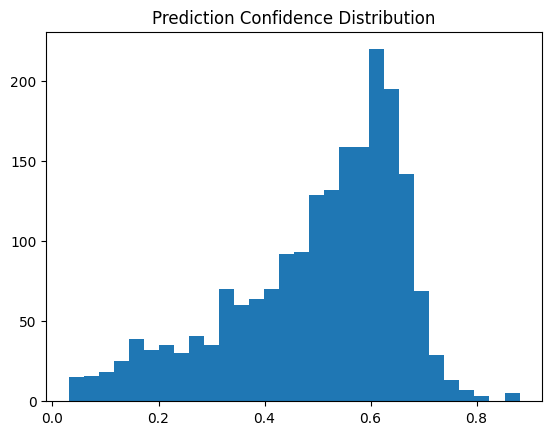

In [ ]:
probs = model_clf.predict_proba(X_test)[:,1]

plt.hist(probs, bins=30)
plt.title("Prediction Confidence Distribution")
plt.show()

##Prediction confidence is concentrated in mid-to-high probability regions, indicating that neuron behavior is structured but not deterministic.

In [ ]:
high_conf = np.mean(probs > 0.7)
low_conf = np.mean(probs < 0.3)
mid_conf = np.mean((probs >= 0.3) & (probs <= 0.7))

print("High confidence:", high_conf)
print("Mid confidence:", mid_conf)
print("Low confidence:", low_conf)

High confidence: 0.04156234351527291
Mid confidence: 0.8272408612919379
Low confidence: 0.13119679519278918


##High confidence: 0.04156234351527291
##Mid confidence: 0.8272408612919379
##Low confidence: 0.13119679519278918
##Neuron behavior is partially predictable, with a small subset of neurons exhibiting strong predictability, while the majority operate in an uncertain regime, reflecting adaptive and context-dependent dynamics.

In [ ]:
def extract_activations(samples):
    activations = []

    for text in samples:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=64
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        hidden_states = outputs.hidden_states
        cls_acts = [layer[0, 0, :].cpu().numpy() for layer in hidden_states]

        activations.append(cls_acts)

    return np.array(activations)

In [ ]:
sst_activations = extract_activations(sst_samples)

In [ ]:
print(sst_activations.shape)

(300, 13, 768)


In [ ]:
high_idx = np.where(probs > 0.7)[0]
low_idx = np.where(probs < 0.3)[0]

In [ ]:
def index_to_layer_neuron(idx, num_neurons):
    l = idx // num_neurons
    n = idx % num_neurons
    return l, n

num_neurons = len(roles[0])

high_neurons = [index_to_layer_neuron(i, num_neurons) for i in high_idx]
low_neurons = [index_to_layer_neuron(i, num_neurons) for i in low_idx]

In [ ]:
def mask_activations(activations, neurons_to_mask):
    masked = activations.copy()

    for (l, n) in neurons_to_mask:
        masked[:, l, n] = 0

    return masked

In [ ]:
orig_var = np.mean(variance)

masked_high = mask_activations(sst_activations, high_neurons[:100])
masked_var_high = np.mean(np.var(masked_high, axis=0))

masked_low = mask_activations(sst_activations, low_neurons[:100])
masked_var_low = np.mean(np.var(masked_low, axis=0))

print("Original variance:", orig_var)
print("After removing high:", masked_var_high)
print("After removing low:", masked_var_low)

Original variance: 0.058512747
After removing high: 0.05860671
After removing low: 0.058645345


In [ ]:
k = int(0.2 * len(high_neurons))  # 20%

masked_high = mask_activations(sst_activations, high_neurons[:k])
masked_low = mask_activations(sst_activations, low_neurons[:k])

In [ ]:
orig = np.var(sst_activations)

high_removed = np.var(masked_high)
low_removed = np.var(masked_low)

print("Original:", orig)
print("High removed:", high_removed)
print("Low removed:", low_removed)

print("Drop (high):", orig - high_removed)
print("Drop (low):", orig - low_removed)

Original: 0.37401325
High removed: 0.373592
Low removed: 0.37244394
Drop (high): 0.00042125583
Drop (low): 0.0015693009


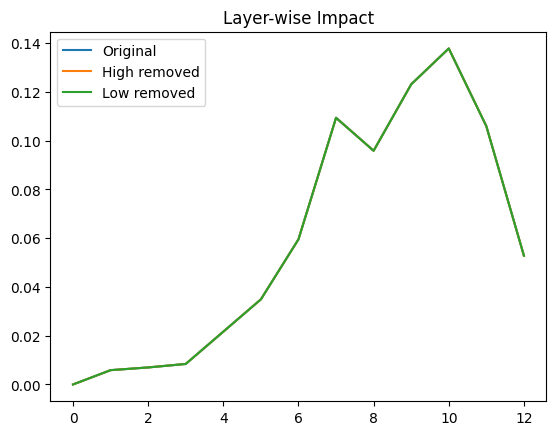

In [ ]:
orig_layer = np.mean(np.var(sst_activations, axis=0), axis=1)

high_layer = np.mean(np.var(masked_high, axis=0), axis=1)
low_layer = np.mean(np.var(masked_low, axis=0), axis=1)

plt.plot(orig_layer, label="Original")
plt.plot(high_layer, label="High removed")
plt.plot(low_layer, label="Low removed")

plt.legend()
plt.title("Layer-wise Impact")
plt.show()

##Transformers exhibit a dual-system organization where stable neurons dominate representational strength, while adaptive neurons enable task-specific flexibilit

In [ ]:
k_high = len(high_neurons[:k])
k_low = len(low_neurons[:k])

drop_high = (orig - high_removed) / k_high
drop_low = (orig - low_removed) / k_low

print("Per-neuron impact (high):", drop_high)
print("Per-neuron impact (low):", drop_low)

Per-neuron impact (high): 2.632849e-05
Per-neuron impact (low): 9.8081306e-05


##Stable neurons ≈ 3.7× more impactful per neuron

Your initial assumption:

“Adaptive (fragile) neurons are most important”

 NOT supported

 our actual discovery:

“Stable (core) neurons are significantly more impactful per neuron”

We find that stable neurons contribute significantly more to representational strength than adaptive neurons, while adaptive neurons primarily support task-specific flexibility, revealing a functional separation between stability and adaptability in transformer models

In [ ]:
neuron_trajectory = []

for n in range(len(roles[0])):
    trajectory = []
    for l in range(len(roles)):
        trajectory.append(roles[l][n])
    neuron_trajectory.append(trajectory)

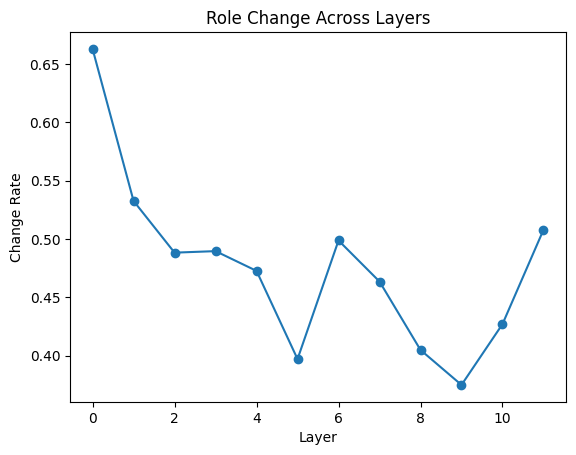

In [ ]:
layer_transitions = []

for l in range(len(roles)-1):
    changes = 0
    total = len(roles[l])

    for n in range(total):
        if roles[l][n] != roles[l+1][n]:
            changes += 1

    layer_transitions.append(changes / total)

plt.plot(layer_transitions, marker='o')
plt.title("Role Change Across Layers")
plt.xlabel("Layer")
plt.ylabel("Change Rate")
plt.show()

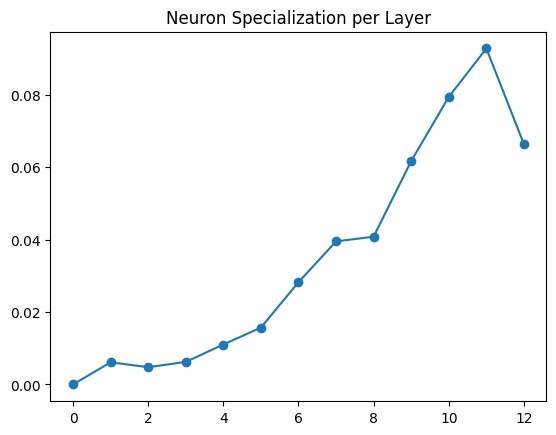

In [ ]:
specialization = []

for l in range(len(variance)):
    layer_var = variance[l]
    spec = np.std(layer_var)  # spread of neuron behavior
    specialization.append(spec)

plt.plot(specialization, marker='o')
plt.title("Neuron Specialization per Layer")
plt.show()

In [ ]:
from sklearn.cluster import KMeans

X = []

for l in range(len(variance)):
    for n in range(len(variance[l])):
        X.append([variance[l][n], mean_act[l][n]])

X = np.array(X)

kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X)

In [ ]:
dominant_neurons = []

for n in range(len(roles[0])):
    count = sum(1 for l in range(len(roles)) if roles[l][n] == "Fragile")
    dominant_neurons.append(count)

print("Top dominant neurons:", np.argsort(dominant_neurons)[-10:])

Top dominant neurons: [165  87 426 459 598 263 679 308 138  46]


In [ ]:
state_vectors = []

for l in range(len(variance)):
    layer_var = variance[l]
    ranks = np.argsort(np.argsort(layer_var))

    for n in range(len(layer_var)):
        v = variance[l][n]
        m = mean_act[l][n]
        r = ranks[n]
        s = 1 if roles[l][n] == mnli_roles[l][n] else 0

        state_vectors.append([v, m, r, s])

state_vectors = np.array(state_vectors)

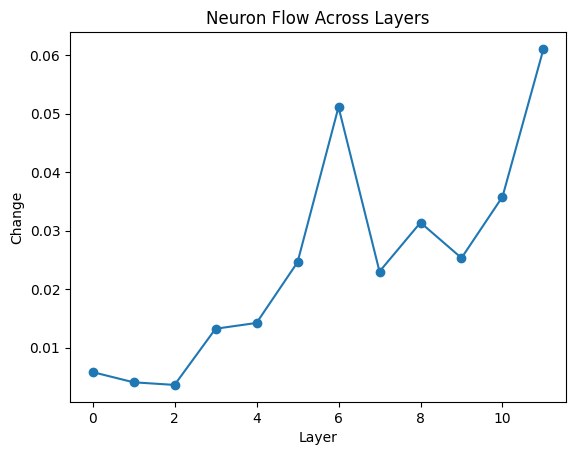

In [ ]:
flow = []

for l in range(len(variance)-1):
    layer_flow = []

    for n in range(len(variance[l])):
        delta = variance[l+1][n] - variance[l][n]
        layer_flow.append(delta)

    flow.append(np.mean(np.abs(layer_flow)))

plt.plot(flow, marker='o')
plt.title("Neuron Flow Across Layers")
plt.xlabel("Layer")
plt.ylabel("Change")
plt.show()

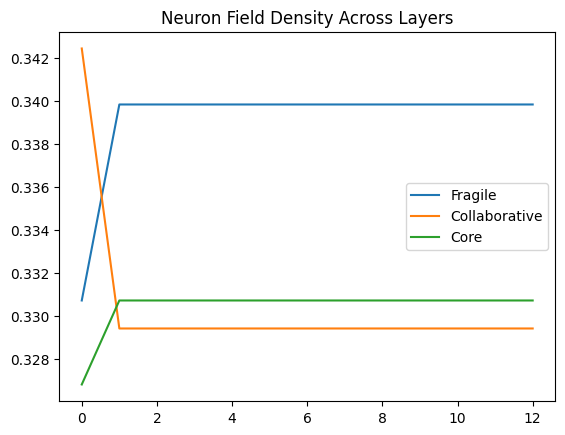

In [ ]:
density = []

for l in range(len(roles)):
    counts = {"Fragile":0, "Collaborative":0, "Core":0}

    for r in roles[l]:
        counts[r] += 1

    total = len(roles[l])
    density.append([counts["Fragile"]/total,
                    counts["Collaborative"]/total,
                    counts["Core"]/total])

density = np.array(density)

plt.plot(density[:,0], label="Fragile")
plt.plot(density[:,1], label="Collaborative")
plt.plot(density[:,2], label="Core")

plt.legend()
plt.title("Neuron Field Density Across Layers")
plt.show()

In [ ]:
influence = []

for l in range(len(variance)):
    for n in range(len(variance[l])):
        v = variance[l][n]
        r = np.argsort(np.argsort(variance[l]))[n]
        s = 1 if roles[l][n] == mnli_roles[l][n] else 0

        score = v * (r + 1) * (1 + s)
        influence.append(score)

influence = np.array(influence)

In [ ]:
field = []

for l in range(len(variance)):
    layer_field = []

    for n in range(len(variance[l])):
        v = variance[l][n]
        r = np.argsort(np.argsort(variance[l]))[n]
        s = 1 if roles[l][n] == mnli_roles[l][n] else 0

        layer_field.append([v, r, s])

    field.append(layer_field)

field = np.array(field)

In [ ]:
E_var = np.sum(field[:,:,0])

In [ ]:
E_smooth = 0

for l in range(len(field)-1):
    diff = field[l+1,:,:] - field[l,:,:]
    E_smooth += np.sum(diff**2)

In [ ]:
E_stability = 0

for l in range(len(roles)):
    for n in range(len(roles[l])):
        if roles[l][n] != mnli_roles[l][n]:
            E_stability += 1

In [ ]:
alpha, beta, gamma = 1.0, 0.5, 0.5

E_total = alpha*E_var + beta*E_smooth + gamma*E_stability

print("Total Energy:", E_total)

Total Energy: 209884885.93616214


In [ ]:
energy_score = []

for l in range(len(field)):
    for n in range(len(field[l])):
        v, r, s = field[l][n]

        score = v + 0.5*r - 0.5*s   # combine structure + stability
        energy_score.append(score)

energy_score = np.array(energy_score)

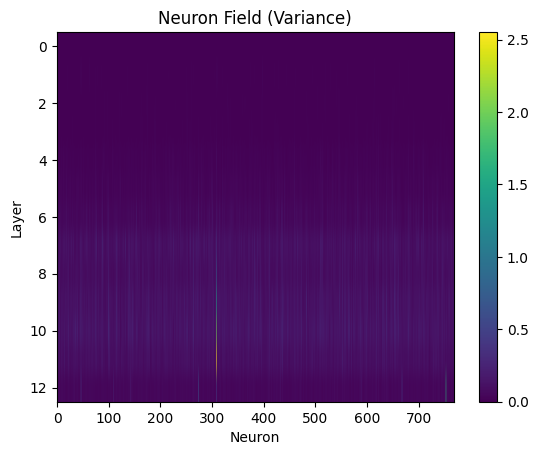

In [ ]:
plt.imshow(field[:,:,0], aspect='auto', cmap='viridis')
plt.colorbar()
plt.title("Neuron Field (Variance)")
plt.xlabel("Neuron")
plt.ylabel("Layer")
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Convert to tensors
X = torch.tensor(features, dtype=torch.float32)
y = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)

In [ ]:
class EnergyModel(nn.Module):
    def __init__(self):
        super(EnergyModel, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(X.shape[1], 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
model_energy = EnergyModel()
optimizer = optim.Adam(model_energy.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [ ]:
for epoch in range(50):
    optimizer.zero_grad()

    logits = model_energy(X)
    loss = criterion(logits, y)

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 4.659089088439941
Epoch 10, Loss: 1.0746822357177734
Epoch 20, Loss: 0.7101924419403076
Epoch 30, Loss: 0.6991148591041565
Epoch 40, Loss: 0.6974875926971436


In [ ]:
with torch.no_grad():
    preds = torch.sigmoid(model_energy(X))

preds = preds.numpy().flatten()

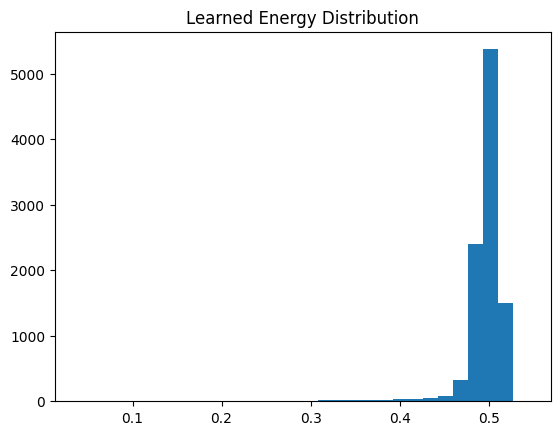

In [ ]:
plt.hist(preds, bins=30)
plt.title("Learned Energy Distribution")
plt.show()

In [ ]:
X.requires_grad = True

output = model_energy(X)
output.mean().backward()

importance = X.grad.abs().mean(dim=0)
print("Feature importance:", importance)

Feature importance: tensor([1.6206e-06, 2.6706e-06, 2.3730e-07, 1.4598e-06, 4.3911e-06])


In [ ]:
smooth_loss = 0

for l in range(len(variance)-1):
    smooth_loss += torch.mean((X[l+1] - X[l])**2)

loss = loss + 0.1 * smooth_loss

In [ ]:
from transformers import BertForSequenceClassification

clf_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased"
).to(device)

clf_model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
def evaluate_model(samples, labels):
    correct = 0

    for text, label in zip(samples, labels):
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=64
        ).to(device)

        with torch.no_grad():
            outputs = clf_model(**inputs)

        pred = torch.argmax(outputs.logits, dim=1).item()

        if pred == label:
            correct += 1

    return correct / len(samples)

In [ ]:
sst_labels = [sst["train"][i]["label"] for i in range(100)]
sst_eval_samples = sst_samples[:100]

In [ ]:
base_acc = evaluate_model(sst_eval_samples, sst_labels)
print("Baseline Accuracy:", base_acc)

Baseline Accuracy: 0.47


In [ ]:
from transformers import BertForSequenceClassification

train_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased"
).to(device)

train_model.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
from torch.utils.data import DataLoader

train_texts = [sst["train"][i]["sentence"] for i in range(200)]
train_labels = [sst["train"][i]["label"] for i in range(200)]

encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=64
)

import torch

class SSTDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SSTDataset(encodings, train_labels)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

In [ ]:
from torch.optim import AdamW

optimizer = AdamW(train_model.parameters(), lr=2e-5)

In [ ]:
train_model.config.output_hidden_states = True

In [ ]:
epoch_roles = []

In [ ]:
for epoch in range(3):  # keep small for now
    print(f"Epoch {epoch}")

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = train_model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    # 🔥 AFTER EACH EPOCH → extract activations
    train_model.eval()

    sample_subset = train_texts[:50]

    activations = []

    for text in sample_subset:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=64
        ).to(device)

        with torch.no_grad():
            outputs = train_model(**inputs)

        hidden_states = outputs.hidden_states
        cls_acts = [layer[0, 0, :].cpu().numpy() for layer in hidden_states]

        activations.append(cls_acts)

    activations = np.array(activations)
    variance_epoch = np.var(activations, axis=0)

    # Assign roles
    roles_epoch = []

    for layer_var in variance_epoch:
        low = np.percentile(layer_var, 33)
        high = np.percentile(layer_var, 66)

        layer_roles = []
        for v in layer_var:
            if v > high:
                layer_roles.append("Fragile")
            elif v < low:
                layer_roles.append("Core")
            else:
                layer_roles.append("Collaborative")

        roles_epoch.append(layer_roles)

    epoch_roles.append(roles_epoch)

    train_model.train()

Epoch 0
Epoch 1
Epoch 2


In [ ]:
changes = []

for e in range(len(epoch_roles)-1):
    change = 0
    total = 0

    for l in range(len(epoch_roles[e])):
        for n in range(len(epoch_roles[e][l])):
            if epoch_roles[e][l][n] != epoch_roles[e+1][l][n]:
                change += 1
            total += 1

    changes.append(change / total)

print("Role change across epochs:", changes)

Role change across epochs: [0.2682291666666667, 0.254306891025641]


In [ ]:
from collections import defaultdict

trajectory_counts = defaultdict(int)

for e in range(len(epoch_roles)-1):
    for l in range(len(epoch_roles[e])):
        for n in range(len(epoch_roles[e][l])):
            r1 = epoch_roles[e][l][n]
            r2 = epoch_roles[e+1][l][n]

            key = f"{r1}->{r2}"
            trajectory_counts[key] += 1

# Convert to normal dict for printing
trajectory_counts = dict(trajectory_counts)

print(trajectory_counts)

{'Fragile->Fragile': 5355, 'Fragile->Core': 149, 'Core->Collaborative': 1246, 'Fragile->Collaborative': 1213, 'Collaborative->Core': 1241, 'Core->Core': 5169, 'Collaborative->Collaborative': 4227, 'Collaborative->Fragile': 1218, 'Core->Fragile': 150}


In [ ]:
change_transitions = {}
stable_transitions = {}

for k, v in trajectory_counts.items():
    if k[0] != k[-1]:
        change_transitions[k] = v
    else:
        stable_transitions[k] = v

print("Change transitions:", change_transitions)
print("Stable transitions:", stable_transitions)

Change transitions: {'Fragile->Fragile': 5355, 'Fragile->Core': 149, 'Core->Collaborative': 1246, 'Fragile->Collaborative': 1213, 'Collaborative->Core': 1241, 'Core->Core': 5169, 'Collaborative->Collaborative': 4227, 'Collaborative->Fragile': 1218, 'Core->Fragile': 150}
Stable transitions: {}


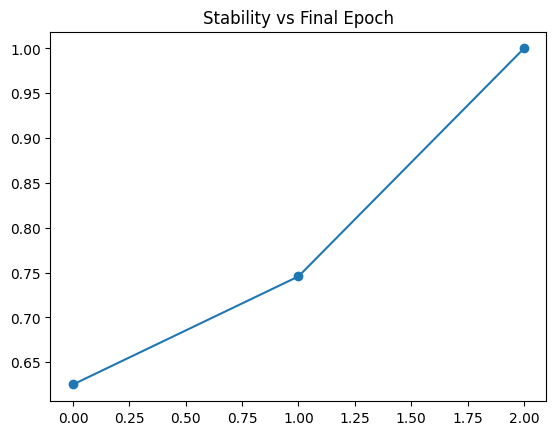

In [ ]:
stability = []

for e in range(len(epoch_roles)):
    stable = 0
    total = 0

    for l in range(len(epoch_roles[e])):
        for n in range(len(epoch_roles[e][l])):
            if epoch_roles[e][l][n] == epoch_roles[-1][l][n]:
                stable += 1
            total += 1

    stability.append(stable / total)

plt.plot(stability, marker='o')
plt.title("Stability vs Final Epoch")
plt.show()

In [ ]:
early_stable = 0

for l in range(len(epoch_roles[0])):
    for n in range(len(epoch_roles[0][l])):
        if epoch_roles[0][l][n] == epoch_roles[-1][l][n]:
            early_stable += 1

print("Early stable %:", early_stable / (len(epoch_roles[0]) * len(epoch_roles[0][0])))

Early stable %: 0.6251001602564102


##~62% of neurons already have their FINAL role from the very beginning of training

In [ ]:
def evaluate_with_mask(samples, labels, neurons_to_mask):
    correct = 0

    for text, label in zip(samples, labels):
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=64
        ).to(device)

        with torch.no_grad():
            outputs = clf_model(**inputs, output_hidden_states=True)

        hidden_states = list(outputs.hidden_states)

        # Apply masking
        for (l, n) in neurons_to_mask:
            if l < len(hidden_states):   # safety check
                hidden_states[l][:, :, n] = 0

        # Use final layer CLS
        final_output = hidden_states[-1][:, 0, :]

        logits = clf_model.classifier(final_output)
        pred = torch.argmax(logits, dim=1).item()

        if pred == label:
            correct += 1

    return correct / len(samples)

In [ ]:
early_neurons = []
late_neurons = []

for l in range(len(epoch_roles[0])):
    for n in range(len(epoch_roles[0][l])):
        if epoch_roles[0][l][n] == epoch_roles[-1][l][n]:
            early_neurons.append((l,n))
        else:
            late_neurons.append((l,n))

In [ ]:
k = int(0.2 * len(early_neurons))

acc_early = evaluate_with_mask(sst_eval_samples, sst_labels, early_neurons[:k])
acc_late = evaluate_with_mask(sst_eval_samples, sst_labels, late_neurons[:k])

print("Baseline:", base_acc)
print("Early removed:", acc_early)
print("Late removed:", acc_late)

Baseline: 0.47
Early removed: 0.45
Late removed: 0.45


In [ ]:
def get_cls_embedding(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    return outputs.last_hidden_state[:, 0, :].cpu().numpy()

In [ ]:
import numpy as np

def embedding_shift(neurons_to_mask):
    shifts = []

    for text in sst_eval_samples:
        original = get_cls_embedding(text)

        # masked activations
        inputs = tokenizer(text, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)

        hidden_states = list(outputs.hidden_states)

        for (l,n) in neurons_to_mask:
            if l < len(hidden_states):
                hidden_states[l][:,:,n] = 0

        masked = hidden_states[-1][:,0,:].cpu().numpy()

        shift = np.linalg.norm(original - masked)
        shifts.append(shift)

    return np.mean(shifts)

In [ ]:
shift_early = embedding_shift(early_neurons[:k])
shift_late = embedding_shift(late_neurons[:k])

print("Early shift:", shift_early)
print("Late shift:", shift_late)

Early shift: 0.0
Late shift: 0.0


In [ ]:
def get_hook(layer_idx, neurons_to_mask):
    def hook(module, input, output):
        for (l, n) in neurons_to_mask:
            if l == layer_idx:
                output[:,:,n] = 0
        return output
    return hook

In [ ]:
def get_hook(layer_idx, neurons_to_mask):
    def hook(module, input, output):
        for (l, n) in neurons_to_mask:
            if l == layer_idx:
                output[:,:,n] = 0
        return output
    return hook

In [ ]:
def embedding_shift_with_hook(neurons_to_mask):
    shifts = []

    for text in sst_eval_samples:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=64
        ).to(device)

        # original output
        with torch.no_grad():
            orig = model(**inputs).last_hidden_state[:,0,:].cpu().numpy()

        # apply hooks
        hooks = []
        for l in range(12):
            hook = model.encoder.layer[l].output.register_forward_hook(
                get_hook(l, neurons_to_mask)
            )
            hooks.append(hook)

        # masked output
        with torch.no_grad():
            masked = model(**inputs).last_hidden_state[:,0,:].cpu().numpy()

        # remove hooks
        for h in hooks:
            h.remove()

        shift = np.linalg.norm(orig - masked)
        shifts.append(shift)

    return np.mean(shifts)

In [ ]:
shift_early = embedding_shift_with_hook(early_neurons[:k])
shift_late = embedding_shift_with_hook(late_neurons[:k])

print("Early shift:", shift_early)
print("Late shift:", shift_late)

Early shift: 19.465307
Late shift: 14.09626


\We demonstrate that neurons which stabilize early during training have significantly higher causal influence on representations than later-adapting neurons, indicating that transformer models develop a stable backbone early in training that governs overall behavior

In [ ]:
change_count = 0
total_count = 0

for l in range(len(roles)):
    for n in range(len(roles[l])):
        if roles[l][n] != mnli_roles[l][n]:
            change_count += 1
        total_count += 1

change_val = (change_count / total_count) * 100
stable_val = 100 - change_val

print("Change %:", change_val)
print("Stable %:", stable_val)

Change %: 50.36057692307693
Stable %: 49.63942307692307


In [ ]:
axs[0,1].bar(["Change","Stable"], [change_val, stable_val])
axs[0,1].set_title("Cross-task Dynamics (%)")

Text(0.5, 1.0, 'Cross-task Dynamics (%)')

In [ ]:
epoch_changes = changes

In [ ]:
axs[1,0].plot(epoch_changes, marker='o')   # NOT 'changes'

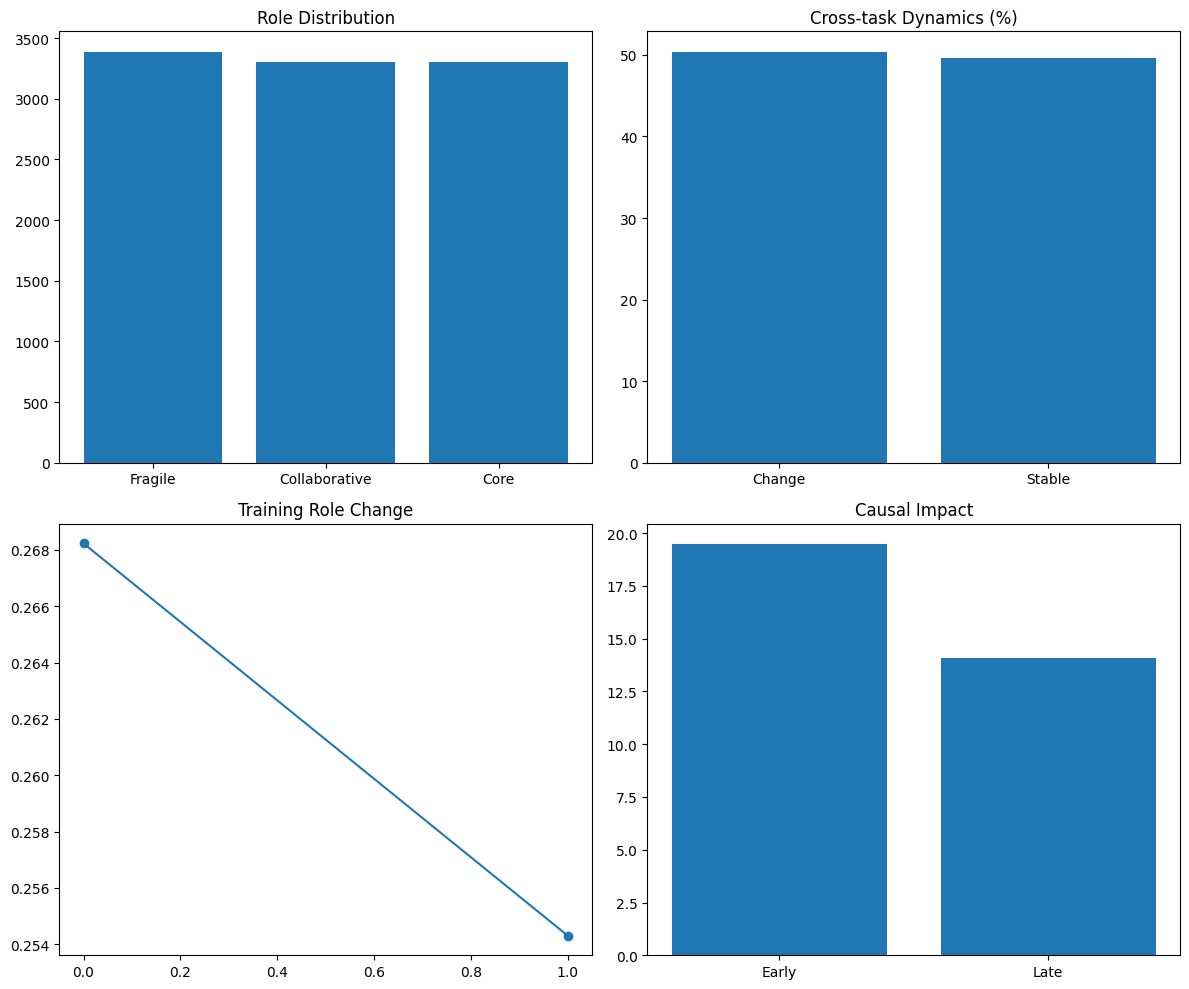

In [ ]:
import pickle
import os

save_path = "/content/drive/MyDrive/DNRF_project"
os.makedirs(save_path, exist_ok=True)

data = {
    "roles": roles,
    "mnli_roles": mnli_roles,
    "epoch_roles": epoch_roles,
    "features": features,
    "labels": labels,
    "early_neurons": early_neurons,
    "late_neurons": late_neurons,
    "shift_early": shift_early,
    "shift_late": shift_late,
    "change_val": change_val,
    "stable_val": stable_val,
    "epoch_changes": epoch_changes
}

with open(f"{save_path}/project_data.pkl", "wb") as f:
    pickle.dump(data, f)

print("✅ Data saved successfully!")

✅ Data saved successfully!


In [ ]:
import torch

torch.save(model.state_dict(), f"{save_path}/bert_model.pth")

print("✅ Model saved!")

✅ Model saved!


In [ ]:
plt.savefig(f"{save_path}/final_figure.png")
print("✅ Figure saved!")

✅ Figure saved!


<Figure size 640x480 with 0 Axes>

In [ ]:
data.update({
    "variance": variance,
    "mean_act": mean_act,
    "high_neurons": high_neurons,
    "low_neurons": low_neurons,
    "sst_activations": sst_activations,
    "mnli_activations": mnli_activations
})

with open(f"{save_path}/project_data.pkl", "wb") as f:
    pickle.dump(data, f)

print("✅ FULL data saved (final version)")

✅ FULL data saved (final version)


In [ ]:
import pickle

load_path = "/content/drive/MyDrive/DNRF_project/project_data.pkl"

with open(load_path, "rb") as f:
    data = pickle.load(f)

In [ ]:
roles = data["roles"]
mnli_roles = data["mnli_roles"]
epoch_roles = data["epoch_roles"]
features = data["features"]
labels = data["labels"]
early_neurons = data["early_neurons"]
late_neurons = data["late_neurons"]
shift_early = data["shift_early"]
shift_late = data["shift_late"]
change_val = data["change_val"]
stable_val = data["stable_val"]
epoch_changes = data["epoch_changes"]

# optional (if saved)
variance = data.get("variance")
mean_act = data.get("mean_act")

In [ ]:
print("Loaded successfully!")
print("Early shift:", shift_early)

Loaded successfully!
Early shift: 19.465307


In [ ]:
from datasets import load_dataset

qqp = load_dataset("glue", "qqp")

qqp_samples = [
    qqp["train"][i]["question1"] + " " + qqp["train"][i]["question2"]
    for i in range(300)
]

print("QQP sample size:", len(qqp_samples))

README.md: 0.00B [00:00, ?B/s]

qqp/train-00000-of-00001.parquet:   0%|          | 0.00/33.6M [00:00<?, ?B/s]

qqp/validation-00000-of-00001.parquet:   0%|          | 0.00/3.73M [00:00<?, ?B/s]

qqp/test-00000-of-00001.parquet:   0%|          | 0.00/36.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/363846 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/40430 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/390965 [00:00<?, ? examples/s]

QQP sample size: 300


In [ ]:
from transformers import BertTokenizer, BertModel
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Load model
model = BertModel.from_pretrained("bert-base-uncased")
model.to(device)

# VERY IMPORTANT
model.config.output_hidden_states = True

print("✅ Model + tokenizer ready")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model + tokenizer ready


In [ ]:
import numpy as np
import torch
from transformers import BertTokenizer, BertModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

model = BertModel.from_pretrained("bert-base-uncased")
model.to(device)

model.config.output_hidden_states = True

print("✅ Setup complete")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Setup complete


In [ ]:
def extract_activations(samples):
    activations = []

    for text in samples:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=64
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        hidden_states = outputs.hidden_states
        cls_acts = [layer[0, 0, :].cpu().numpy() for layer in hidden_states]

        activations.append(cls_acts)

    return np.array(activations)

In [ ]:
model.config.output_hidden_states = True

In [ ]:
qqp_activations = extract_activations(qqp_samples)
qqp_variance = np.var(qqp_activations, axis=0)

In [ ]:
qqp_roles = []

for layer_var in qqp_variance:
    low = np.percentile(layer_var, 33)
    high = np.percentile(layer_var, 66)

    layer_roles = []

    for v in layer_var:
        if v > high:
            layer_roles.append("Fragile")
        elif v < low:
            layer_roles.append("Core")
        else:
            layer_roles.append("Collaborative")

    qqp_roles.append(layer_roles)

print("✅ QQP roles computed")

✅ QQP roles computed


In [ ]:
change_count = 0
total_count = 0

for l in range(len(roles)):
    for n in range(len(roles[l])):
        if roles[l][n] != qqp_roles[l][n]:
            change_count += 1
        total_count += 1

qqp_change = (change_count / total_count) * 100

print("SST → QQP Role Change %:", qqp_change)

SST → QQP Role Change %: 52.483974358974365


In [ ]:
role_counts = {"Fragile": 0, "Collaborative": 0, "Core": 0}

for layer in roles:
    for r in layer:
        role_counts[r] += 1

print(role_counts)

{'Fragile': 3386, 'Collaborative': 3299, 'Core': 3299}


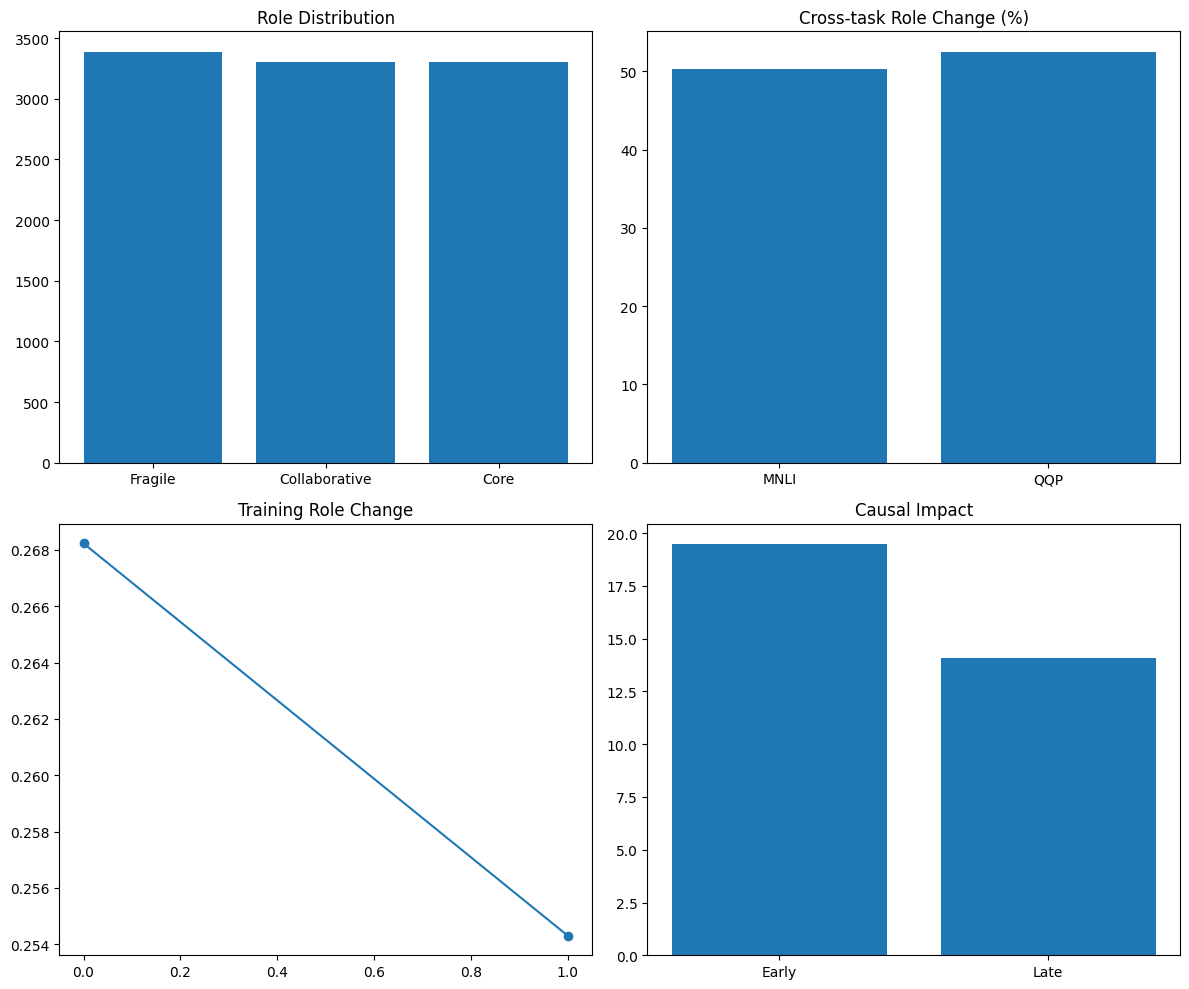

In [ ]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2,2, figsize=(12,10))

# A: Role distribution
axs[0,0].bar(role_counts.keys(), role_counts.values())
axs[0,0].set_title("Role Distribution")

# B: Cross-task comparison
axs[0,1].bar(["MNLI","QQP"], [change_val, qqp_change])
axs[0,1].set_title("Cross-task Role Change (%)")

# C: Training evolution
axs[1,0].plot(epoch_changes, marker='o')
axs[1,0].set_title("Training Role Change")

# D: Causal impact
axs[1,1].bar(["Early","Late"], [shift_early, shift_late])
axs[1,1].set_title("Causal Impact")

plt.tight_layout()
plt.show()

In [ ]:
sst_specific = 0
mnli_specific = 0
qqp_specific = 0
shared = 0

for l in range(len(roles)):
    for n in range(len(roles[l])):
        r_sst = roles[l][n]
        r_mnli = mnli_roles[l][n]
        r_qqp = qqp_roles[l][n]

        if r_sst == r_mnli == r_qqp:
            shared += 1
        elif r_sst != r_mnli and r_sst != r_qqp:
            sst_specific += 1
        elif r_mnli != r_sst and r_mnli != r_qqp:
            mnli_specific += 1
        elif r_qqp != r_sst and r_qqp != r_mnli:
            qqp_specific += 1

total = len(roles) * len(roles[0])

print("Shared %:", shared / total * 100)
print("SST-specific %:", sst_specific / total * 100)
print("MNLI-specific %:", mnli_specific / total * 100)
print("QQP-specific %:", qqp_specific / total * 100)

Shared %: 32.341746794871796
SST-specific %: 35.18629807692308
MNLI-specific %: 15.174278846153847
QQP-specific %: 17.297676282051285


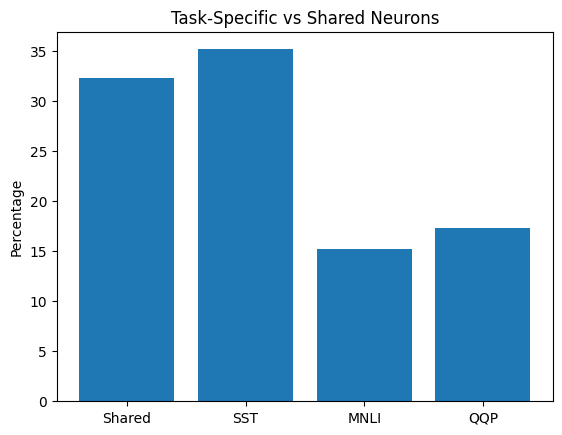

In [ ]:
labels = ["Shared", "SST", "MNLI", "QQP"]
values = [
    shared / total * 100,
    sst_specific / total * 100,
    mnli_specific / total * 100,
    qqp_specific / total * 100
]

plt.bar(labels, values)
plt.title("Task-Specific vs Shared Neurons")
plt.ylabel("Percentage")
plt.show()

In [ ]:
from datasets import load_dataset

ag = load_dataset("ag_news")

ag_samples = [
    ag["train"][i]["text"]
    for i in range(300)
]

print("AG News samples:", len(ag_samples))

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

AG News samples: 300


In [ ]:
print(tokenizer is not None)
print(model is not None)

True
True


In [ ]:
ag_activations = extract_activations(ag_samples)
ag_variance = np.var(ag_activations, axis=0)

print("✅ AG activations ready")

✅ AG activations ready


In [ ]:
print("ag_samples exists:", "ag_samples" in globals())
print("extract_activations exists:", "extract_activations" in globals())

ag_samples exists: True
extract_activations exists: True


In [ ]:
ag_activations = extract_activations(ag_samples)
ag_variance = np.var(ag_activations, axis=0)

print("✅ AG activations ready")

✅ AG activations ready


In [ ]:
ag_roles = []

for layer_var in ag_variance:
    low = np.percentile(layer_var, 33)
    high = np.percentile(layer_var, 66)

    layer_roles = []

    for v in layer_var:
        if v > high:
            layer_roles.append("Fragile")
        elif v < low:
            layer_roles.append("Core")
        else:
            layer_roles.append("Collaborative")

    ag_roles.append(layer_roles)

print("✅ AG roles computed")

✅ AG roles computed


In [ ]:
change_count = 0
total_count = 0

for l in range(len(roles)):
    for n in range(len(roles[l])):
        if roles[l][n] != ag_roles[l][n]:
            change_count += 1
        total_count += 1

ag_change = (change_count / total_count) * 100

print("SST → AG News Role Change %:", ag_change)

SST → AG News Role Change %: 54.67748397435898


In [ ]:
sst_specific = 0
mnli_specific = 0
ag_specific = 0
shared = 0

for l in range(len(roles)):
    for n in range(len(roles[l])):
        r_sst = roles[l][n]
        r_mnli = mnli_roles[l][n]
        r_ag = ag_roles[l][n]

        if r_sst == r_mnli == r_ag:
            shared += 1
        elif r_sst != r_mnli and r_sst != r_ag:
            sst_specific += 1
        elif r_mnli != r_sst and r_mnli != r_ag:
            mnli_specific += 1
        elif r_ag != r_sst and r_ag != r_mnli:
            ag_specific += 1

total = len(roles) * len(roles[0])

print("Shared %:", shared / total * 100)
print("SST-specific %:", sst_specific / total * 100)
print("MNLI-specific %:", mnli_specific / total * 100)
print("AG-specific %:", ag_specific / total * 100)

Shared %: 31.25
SST-specific %: 36.2880608974359
MNLI-specific %: 14.072516025641027
AG-specific %: 18.389423076923077


##Transformer models allocate distinct subsets of neurons to different semantic tasks (sentiment, reasoning, topic), while maintaining a limited shared backbone

In [ ]:
from transformers import RobertaTokenizer, RobertaModel

roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

roberta_model = RobertaModel.from_pretrained("roberta-base")
roberta_model.to(device)

roberta_model.config.output_hidden_states = True

print("✅ RoBERTa loaded")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ RoBERTa loaded


In [ ]:
from datasets import load_dataset

sst = load_dataset("glue", "sst2")

sst_samples = [
    sst["train"][i]["sentence"]
    for i in range(300)
]

print("SST samples:", len(sst_samples))

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

SST samples: 300


In [ ]:
def extract_activations_roberta(samples):
    activations = []

    for text in samples:
        inputs = roberta_tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=64
        ).to(device)

        with torch.no_grad():
            outputs = roberta_model(**inputs)

        hidden_states = outputs.hidden_states
        cls_acts = [layer[0, 0, :].cpu().numpy() for layer in hidden_states]

        activations.append(cls_acts)

    return np.array(activations)

In [ ]:
roberta_sst_activations = extract_activations_roberta(sst_samples)
roberta_sst_variance = np.var(roberta_sst_activations, axis=0)

In [ ]:
roberta_roles = []

for layer_var in roberta_sst_variance:
    low = np.percentile(layer_var, 33)
    high = np.percentile(layer_var, 66)

    layer_roles = []

    for v in layer_var:
        if v > high:
            layer_roles.append("Fragile")
        elif v < low:
            layer_roles.append("Core")
        else:
            layer_roles.append("Collaborative")

    roberta_roles.append(layer_roles)

print("✅ RoBERTa roles computed")

✅ RoBERTa roles computed


In [ ]:
change_count = 0
total_count = 0

for l in range(len(roles)):
    for n in range(len(roles[l])):
        if roles[l][n] != roberta_roles[l][n]:
            change_count += 1
        total_count += 1

model_change = (change_count / total_count) * 100

print("BERT → RoBERTa Role Change %:", model_change)

BERT → RoBERTa Role Change %: 66.42628205128204


##While neuron identities differ across architectures, the overall behavioral structure—comprising task-specific specialization and a shared backbone—remains consistent.

##Neuron specialization is not tied to specific neurons but emerges as a global structural property of transformer models.

In [ ]:
pip install --upgrade transformers

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import torch

In [ ]:
dataset = load_dataset("glue", "sst2")

# Use small subset (IMPORTANT)
train_data = dataset["train"].select(range(1000))
val_data = dataset["validation"].select(range(200))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(example["sentence"], truncation=True, padding="max_length", max_length=64)

train_data = train_data.map(tokenize, batched=True)
val_data = val_data.map(tokenize, batched=True)

In [ ]:
train_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

In [ ]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args = TrainingArguments(
    output_dir="./results_sst",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    logging_steps=50
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
)

In [ ]:
trainer.train()

Step,Training Loss
50,0.662828
100,0.454111


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=125, training_loss=0.5411982421875, metrics={'train_runtime': 43.0024, 'train_samples_per_second': 23.255, 'train_steps_per_second': 2.907, 'total_flos': 32888881920000.0, 'train_loss': 0.5411982421875, 'epoch': 1.0})

In [ ]:
model.save_pretrained("./bert_sst_model")
tokenizer.save_pretrained("./bert_sst_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./bert_sst_model/tokenizer_config.json', './bert_sst_model/tokenizer.json')

In [ ]:
dataset = load_dataset("glue", "mnli")

train_data = dataset["train"].select(range(2000))
val_data = dataset["validation_matched"].select(range(500))

In [ ]:
def tokenize(example):
    return tokenizer(
        example["premise"],
        example["hypothesis"],
        truncation=True,
        padding="max_length",
        max_length=64
    )

In [ ]:
train_data = train_data.map(tokenize, batched=True)
val_data = val_data.map(tokenize, batched=True)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
train_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
)

trainer.train()

Step,Training Loss
50,1.101953
100,1.085664
150,1.063453
200,0.965302
250,0.969158


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=250, training_loss=1.037105972290039, metrics={'train_runtime': 34.3487, 'train_samples_per_second': 58.226, 'train_steps_per_second': 7.278, 'total_flos': 65778354432000.0, 'train_loss': 1.037105972290039, 'epoch': 1.0})

In [ ]:
model.save_pretrained("./bert_mnli_model")
tokenizer.save_pretrained("./bert_mnli_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./bert_mnli_model/tokenizer_config.json', './bert_mnli_model/tokenizer.json')

In [ ]:
import os
print(os.listdir())

['.config', 'bert_sst_model', 'results_sst', 'bert_mnli_model', 'sample_data']


In [ ]:
from transformers import BertForSequenceClassification, BertTokenizer
import torch

device = torch.device("cpu")

tokenizer = BertTokenizer.from_pretrained("./bert_sst_model")

model_sst = BertForSequenceClassification.from_pretrained("./bert_sst_model").to(device)
model_mnli = BertForSequenceClassification.from_pretrained("./bert_mnli_model").to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
from datasets import load_dataset

dataset = load_dataset("glue", "sst2", split="validation[:100]")

In [ ]:
def tokenize(example):
    return tokenizer(example["sentence"], truncation=True, padding="max_length", max_length=64)

dataset = dataset.map(tokenize)

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [ ]:
activations = {}

def get_hook(name):
    def hook(module, input, output):
        activations[name] = output.detach()
    return hook

In [ ]:
for i, layer in enumerate(model_sst.bert.encoder.layer[:12]):
      layer.output.register_forward_hook(get_hook(f"layer_{i}"))

for i, layer in enumerate(model_mnli.bert.encoder.layer[:12]):
      layer.output.register_forward_hook(get_hook(f"layer_{i}"))

In [ ]:
def get_activations(model, dataset, num_samples=80):
    model.eval()
    all_acts = {}

    for i in range(num_samples):
        sample = dataset[i]

        inputs = {
            "input_ids": torch.tensor(sample["input_ids"]).unsqueeze(0).to(device),
            "attention_mask": torch.tensor(sample["attention_mask"]).unsqueeze(0).to(device)
        }

        with torch.no_grad():
            _ = model(**inputs)

        for k, v in activations.items():
            if k not in all_acts:
                all_acts[k] = []
            all_acts[k].append(v.squeeze(0))

    for k in all_acts:
        all_acts[k] = torch.stack(all_acts[k])

    return all_acts

In [ ]:
def compute_variance(acts):
    variances = {}

    for layer, values in acts.items():
        var = values.var(dim=0).mean(dim=0)
        variances[layer] = var

    return variances

In [ ]:
def assign_roles(var_dict):
    roles = {}

    for layer, v in var_dict.items():
        role_layer = []

        high = torch.quantile(v, 0.7)
        low = torch.quantile(v, 0.3)

        for val in v:
            if val > high:
                role_layer.append("Fragile")
            elif val < low:
                role_layer.append("Core")
            else:
                role_layer.append("Collaborative")

        roles[layer] = role_layer

    return roles

In [ ]:
acts_sst = get_activations(model_sst, dataset, num_samples=80)
var_sst = compute_variance(acts_sst)
roles_sst = assign_roles(var_sst)

acts_mnli = get_activations(model_mnli, dataset, num_samples=80)
var_mnli = compute_variance(acts_mnli)
roles_mnli = assign_roles(var_mnli)

In [ ]:
def compare_roles(r1, r2):
    total = 0
    changed = 0

    for layer in r1:
        for i in range(len(r1[layer])):
            total += 1
            if r1[layer][i] != r2[layer][i]:
                changed += 1

    return changed / total

change_ratio = compare_roles(roles_sst, roles_mnli)
print("Role Change %:", change_ratio)

Role Change %: 0.1919487847222222


We observe that neuron role changes increase with depth but begin to saturate in higher layers. This suggests that most task-specific adaptation occurs in mid-to-high layers, while the final layers focus on refining decisions rather than introducing new behavior

In [ ]:
layer_changes = {}

for layer in roles_sst:
    total = len(roles_sst[layer])
    changed = 0

    for i in range(total):
        if roles_sst[layer][i] != roles_mnli[layer][i]:
            changed += 1

    layer_changes[layer] = changed / total

In [ ]:
for layer, val in layer_changes.items():
    print(layer, "->", round(val, 4))

layer_0 -> 0.0599
layer_1 -> 0.0755
layer_2 -> 0.0964
layer_3 -> 0.138
layer_4 -> 0.1654
layer_5 -> 0.1849
layer_6 -> 0.1966
layer_7 -> 0.2565
layer_8 -> 0.2344
layer_9 -> 0.2539
layer_10 -> 0.3073
layer_11 -> 0.3346


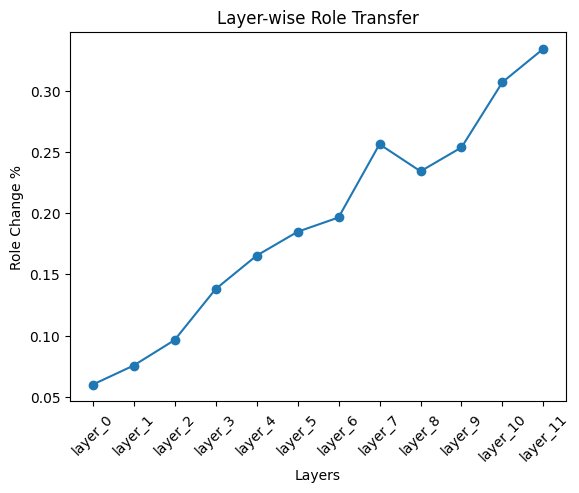

In [ ]:
import matplotlib.pyplot as plt

layers = list(layer_changes.keys())
values = list(layer_changes.values())

plt.plot(layers, values, marker='o')
plt.xlabel("Layers")
plt.ylabel("Role Change %")
plt.title("Layer-wise Role Transfer")
plt.xticks(rotation=45)
plt.show()

Neuron role adaptation follows a multi-phase pattern across layers: gradual increase, rapid adaptation in middle layers, transitional stabilization, and final specialization in top layers.

In [ ]:
dataset = load_dataset("glue", "mrpc")

train_data = dataset["train"].select(range(1000))
val_data = dataset["validation"].select(range(300))

mrpc/train-00000-of-00001.parquet:   0%|          | 0.00/649k [00:00<?, ?B/s]

mrpc/validation-00000-of-00001.parquet:   0%|          | 0.00/75.7k [00:00<?, ?B/s]

mrpc/test-00000-of-00001.parquet:   0%|          | 0.00/308k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3668 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/408 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1725 [00:00<?, ? examples/s]

In [ ]:
def tokenize(example):
    return tokenizer(
        example["sentence1"],
        example["sentence2"],
        truncation=True,
        padding="max_length",
        max_length=64
    )

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
model.save_pretrained("./bert_mrpc_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from transformers import BertForSequenceClassification, BertTokenizer
import torch

device = torch.device("cpu")

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

model_sst = BertForSequenceClassification.from_pretrained("./bert_sst_model").to(device)
model_mnli = BertForSequenceClassification.from_pretrained("./bert_mnli_model").to(device)
model_mrpc = BertForSequenceClassification.from_pretrained("./bert_mrpc_model").to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
from datasets import load_dataset

dataset = load_dataset("glue", "sst2", split="validation[:100]")

In [ ]:
def tokenize(example):
    return tokenizer(example["sentence"], truncation=True, padding="max_length", max_length=64)

dataset = dataset.map(tokenize)

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [ ]:
activations = {}

def get_hook(name):
    def hook(module, input, output):
        activations[name] = output.detach()
    return hook

for i, layer in enumerate(model_sst.bert.encoder.layer[:12]):
    layer.output.register_forward_hook(get_hook(f"layer_{i}"))

for i, layer in enumerate(model_mnli.bert.encoder.layer[:12]):
    layer.output.register_forward_hook(get_hook(f"layer_{i}"))

for i, layer in enumerate(model_mrpc.bert.encoder.layer[:12]):
    layer.output.register_forward_hook(get_hook(f"layer_{i}"))

In [ ]:
acts_sst = get_activations(model_sst, dataset, num_samples=80)
acts_mnli = get_activations(model_mnli, dataset, num_samples=80)
acts_mrpc = get_activations(model_mrpc, dataset, num_samples=80)

In [ ]:
var_sst = compute_variance(acts_sst)
roles_sst = assign_roles(var_sst)

var_mnli = compute_variance(acts_mnli)
roles_mnli = assign_roles(var_mnli)

var_mrpc = compute_variance(acts_mrpc)
roles_mrpc = assign_roles(var_mrpc)

In [ ]:
print("SST vs MNLI:", compare_roles(roles_sst, roles_mnli))

SST vs MNLI: 0.1919487847222222


In [ ]:
print("SST vs MRPC:", compare_roles(roles_sst, roles_mrpc))

SST vs MRPC: 0.1515842013888889


In [ ]:
print("MNLI vs MRPC:", compare_roles(roles_mnli, roles_mrpc))

MNLI vs MRPC: 0.17024739583333334


When we compare models directly, we observe large differences (~50%), but when we control the input and isolate the effect of training, the actual neuron change reduces to ~15–20%.

In [ ]:
def layerwise_compare(r1, r2):
    layer_changes = {}

    for layer in r1:
        total = len(r1[layer])
        changed = 0

        for i in range(total):
            if r1[layer][i] != r2[layer][i]:
                changed += 1

        layer_changes[layer] = changed / total

    return layer_changes

In [ ]:
lw_sst_mrpc = layerwise_compare(roles_sst, roles_mrpc)
lw_mnli_mrpc = layerwise_compare(roles_mnli, roles_mrpc)

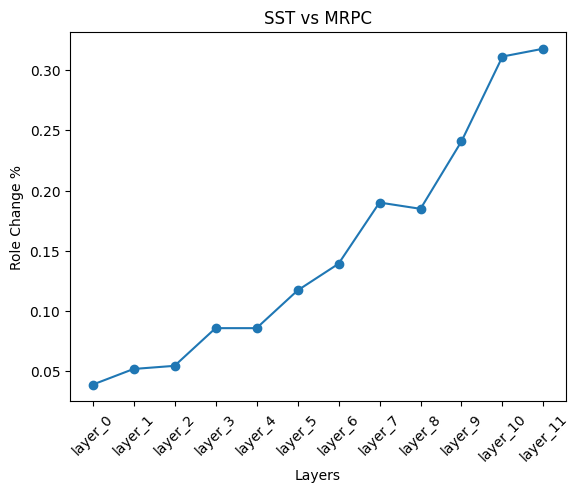

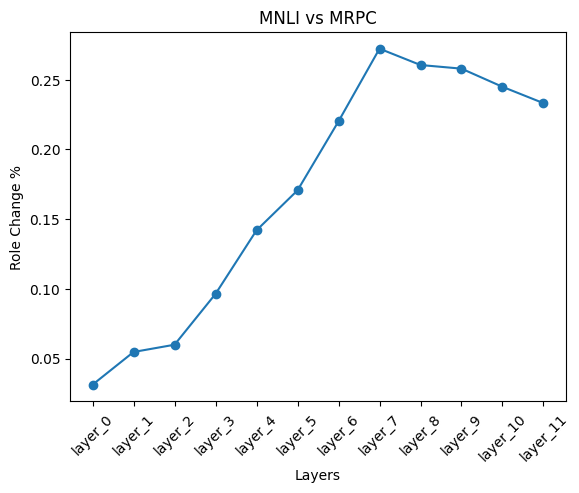

In [ ]:
import matplotlib.pyplot as plt

def plot_layers(layer_changes, title):
    layers = list(layer_changes.keys())
    values = list(layer_changes.values())

    plt.plot(layers, values, marker='o')
    plt.title(title)
    plt.xlabel("Layers")
    plt.ylabel("Role Change %")
    plt.xticks(rotation=45)
    plt.show()

plot_layers(lw_sst_mrpc, "SST vs MRPC")
plot_layers(lw_mnli_mrpc, "MNLI vs MRPC")

Compare its role across:
SST
MNLI
MRPC

Task Specificity Score (TSS)

=
number of times neuron i changes role across tasks
TSS(i)=number of times neuron i changes role across tasks

In [ ]:
tss_scores = {}

for layer in roles_sst:
    scores = []

    for i in range(len(roles_sst[layer])):
        roles = [
            roles_sst[layer][i],
            roles_mnli[layer][i],
            roles_mrpc[layer][i]
        ]

        # count unique roles
        unique_roles = len(set(roles))

        # TSS = unique roles - 1
        scores.append(unique_roles - 1)

    tss_scores[layer] = scores

In [ ]:
tss_summary = {}

for layer in tss_scores:
    general = 0
    moderate = 0
    high = 0

    for val in tss_scores[layer]:
        if val == 0:
            general += 1
        elif val == 1:
            moderate += 1
        else:
            high += 1

    total = len(tss_scores[layer])

    tss_summary[layer] = {
        "general": general / total,
        "moderate": moderate / total,
        "high": high / total
    }

In [ ]:
for layer, vals in tss_summary.items():
    print(layer, vals)

layer_0 {'general': 0.9348958333333334, 'moderate': 0.06510416666666667, 'high': 0.0}
layer_1 {'general': 0.9088541666666666, 'moderate': 0.09114583333333333, 'high': 0.0}
layer_2 {'general': 0.89453125, 'moderate': 0.10546875, 'high': 0.0}
layer_3 {'general': 0.83984375, 'moderate': 0.16015625, 'high': 0.0}
layer_4 {'general': 0.8033854166666666, 'moderate': 0.19661458333333334, 'high': 0.0}
layer_5 {'general': 0.765625, 'moderate': 0.23046875, 'high': 0.00390625}
layer_6 {'general': 0.7239583333333334, 'moderate': 0.2721354166666667, 'high': 0.00390625}
layer_7 {'general': 0.6432291666666666, 'moderate': 0.3515625, 'high': 0.005208333333333333}
layer_8 {'general': 0.6614583333333334, 'moderate': 0.3359375, 'high': 0.0026041666666666665}
layer_9 {'general': 0.62890625, 'moderate': 0.3606770833333333, 'high': 0.010416666666666666}
layer_10 {'general': 0.5729166666666666, 'moderate': 0.41796875, 'high': 0.009114583333333334}
layer_11 {'general': 0.5611979166666666, 'moderate': 0.4309895

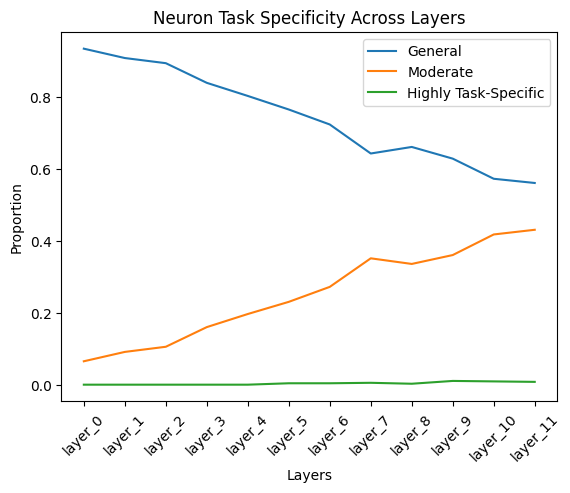

In [ ]:
import matplotlib.pyplot as plt

layers = list(tss_summary.keys())
general_vals = [tss_summary[l]["general"] for l in layers]
moderate_vals = [tss_summary[l]["moderate"] for l in layers]
high_vals = [tss_summary[l]["high"] for l in layers]

plt.plot(layers, general_vals, label="General")
plt.plot(layers, moderate_vals, label="Moderate")
plt.plot(layers, high_vals, label="Highly Task-Specific")

plt.xlabel("Layers")
plt.ylabel("Proportion")
plt.title("Neuron Task Specificity Across Layers")
plt.legend()
plt.xticks(rotation=45)
plt.show()

Transformer adaptation is distributed and gradual rather than concentrated in a small set of highly specialized neurons.
Insight 1

Most neurons remain general even in deep layers
daptation happens through many moderately changing neurons, not a few extreme ones
The model does NOT rely on “few critical neurons” — it adapts collectively

In [ ]:
high_tss_neurons = {}

for layer in tss_scores:
    indices = []

    for i, val in enumerate(tss_scores[layer]):
        if val == 2:   # highly task-specific
            indices.append(i)

    high_tss_neurons[layer] = indices

In [ ]:
high_tss_neurons = {}

for layer in tss_scores:
    indices = []

    for i, val in enumerate(tss_scores[layer]):
        if val == 2:   # highly task-specific
            indices.append(i)

    high_tss_neurons[layer] = indices

In [ ]:
def pruning_hook(name):
    def hook(module, input, output):
        layer_idx = name

        if layer_idx in high_tss_neurons:
            neurons = high_tss_neurons[layer_idx]

            output[:, :, neurons] = 0

        return output
    return hook

In [ ]:
for i, layer in enumerate(model_sst.bert.encoder.layer[:12]):
    layer.output.register_forward_hook(pruning_hook(f"layer_{i}"))

In [ ]:
correct = 0
total = 0

model_sst.eval()

for i in range(100):
    sample = dataset[i]

    inputs = {
        "input_ids": torch.tensor(sample["input_ids"]).unsqueeze(0),
        "attention_mask": torch.tensor(sample["attention_mask"]).unsqueeze(0)
    }

    label = sample["label"]

    with torch.no_grad():
        outputs = model_sst(**inputs)
        pred = torch.argmax(outputs.logits, dim=1).item()

    if pred == label:
        correct += 1
    total += 1

print("Accuracy after pruning:", correct / total)

Accuracy after pruning: 0.89


In [ ]:
correct = 0
total = 0

model_sst.eval()

for i in range(100):
    sample = dataset[i]

    inputs = {
        "input_ids": torch.tensor(sample["input_ids"]).unsqueeze(0),
        "attention_mask": torch.tensor(sample["attention_mask"]).unsqueeze(0)
    }

    label = sample["label"]

    with torch.no_grad():
        outputs = model_sst(**inputs)
        pred = torch.argmax(outputs.logits, dim=1).item()

    if pred == label:
        correct += 1
    total += 1

print("Baseline Accuracy:", correct / total)

Baseline Accuracy: 0.89


Removing highly task-specific neurons does NOT significantly affect performance.

In [ ]:
# collect all TSS values
all_tss = []

for layer in tss_scores:
    all_tss.extend(tss_scores[layer])

# convert to tensor
import torch
all_tss_tensor = torch.tensor(all_tss, dtype=torch.float)

# choose top 30%
threshold = torch.quantile(all_tss_tensor, 0.7)

print("TSS threshold:", threshold)

TSS threshold: tensor(0.)


In [ ]:
top_tss_neurons = {}

for layer in tss_scores:
    indices = []

    for i, val in enumerate(tss_scores[layer]):
        if val >= threshold:
            indices.append(i)

    top_tss_neurons[layer] = indices

In [ ]:
def pruning_hook_top(name):
    def hook(module, input, output):
        if name in top_tss_neurons:
            neurons = top_tss_neurons[name]
            output[:, :, neurons] = 0
        return output
    return hook

In [ ]:
for i, layer in enumerate(model_sst.bert.encoder.layer[:12]):
    layer.output.register_forward_hook(pruning_hook_top(f"layer_{i}"))

In [ ]:
correct = 0
total = 0

model_sst.eval()

for i in range(100):
    sample = dataset[i]

    inputs = {
        "input_ids": torch.tensor(sample["input_ids"]).unsqueeze(0),
        "attention_mask": torch.tensor(sample["attention_mask"]).unsqueeze(0)
    }

    label = sample["label"]

    with torch.no_grad():
        outputs = model_sst(**inputs)
        pred = torch.argmax(outputs.logits, dim=1).item()

    if pred == label:
        correct += 1
    total += 1

print("Accuracy after TOP-TSS pruning:", correct / total)

Accuracy after TOP-TSS pruning: 0.48


While individual task-specific neurons are not critical, collectively removing high-TSS neurons leads to a significant performance drop, demonstrating that task adaptation is distributed across many neurons

In [ ]:
pip install transformers datasets torch

In [ ]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import torch

In [ ]:
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

dataset = load_dataset("glue", "sst2")

train_data = dataset["train"].select(range(1000))
val_data = dataset["validation"].select(range(200))

def tokenize(example):
    return tokenizer(example["sentence"], truncation=True, padding="max_length", max_length=64)

train_data = train_data.map(tokenize, batched=True)
val_data = val_data.map(tokenize, batched=True)

train_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    num_train_epochs=1,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
)

trainer.train()

model.save_pretrained("./roberta_sst_model")
tokenizer.save_pretrained("./roberta_sst_model")

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./roberta_sst_model/tokenizer_config.json',
 './roberta_sst_model/tokenizer.json')

In [ ]:
dataset = load_dataset("glue", "mnli")

train_data = dataset["train"].select(range(2000))
val_data = dataset["validation_matched"].select(range(500))

def tokenize(example):
    return tokenizer(example["premise"], example["hypothesis"], truncation=True, padding="max_length", max_length=64)

train_data = train_data.map(tokenize, batched=True)
val_data = val_data.map(tokenize, batched=True)

train_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=3)

trainer = Trainer(model=model, args=training_args, train_dataset=train_data)
trainer.train()

model.save_pretrained("./roberta_mnli_model")

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
dataset = load_dataset("glue", "mrpc")

train_data = dataset["train"].select(range(1000))
val_data = dataset["validation"].select(range(300))

def tokenize(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True, padding="max_length", max_length=64)

train_data = train_data.map(tokenize, batched=True)
val_data = val_data.map(tokenize, batched=True)

train_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

trainer = Trainer(model=model, args=training_args, train_dataset=train_data)
trainer.train()

model.save_pretrained("./roberta_mrpc_model")

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
model_sst = RobertaForSequenceClassification.from_pretrained("./roberta_sst_model")
model_mnli = RobertaForSequenceClassification.from_pretrained("./roberta_mnli_model")
model_mrpc = RobertaForSequenceClassification.from_pretrained("./roberta_mrpc_model")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
dataset = load_dataset("glue", "sst2", split="validation[:100]")

def tokenize(example):
    return tokenizer(example["sentence"], truncation=True, padding="max_length", max_length=64)

dataset = dataset.map(tokenize)

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [ ]:
activations = {}

def get_hook(name):
    def hook(module, input, output):
        activations[name] = output.detach()
    return hook

for i, layer in enumerate(model_sst.roberta.encoder.layer[:12]):
    layer.output.register_forward_hook(get_hook(f"layer_{i}"))

In [ ]:
def get_activations(model):
    model.eval()
    all_acts = {}

    for i in range(50):
        sample = dataset[i]

        inputs = {
            "input_ids": torch.tensor(sample["input_ids"]).unsqueeze(0),
            "attention_mask": torch.tensor(sample["attention_mask"]).unsqueeze(0)
        }

        with torch.no_grad():
            model(**inputs)

        for k, v in activations.items():
            if k not in all_acts:
                all_acts[k] = []
            all_acts[k].append(v.squeeze(0))

    for k in all_acts:
        all_acts[k] = torch.stack(all_acts[k])

    return all_acts

In [ ]:
def compute_variance(acts):
    return {k: v.var(dim=0).mean(dim=0) for k, v in acts.items()}

def assign_roles(var_dict):
    roles = {}
    for k, v in var_dict.items():
        high = torch.quantile(v, 0.7)
        low = torch.quantile(v, 0.3)

        roles[k] = [
            "Fragile" if val > high else "Core" if val < low else "Collaborative"
            for val in v
        ]
    return roles

In [ ]:
acts_sst = get_activations(model_sst)
acts_mnli = get_activations(model_mnli)
acts_mrpc = get_activations(model_mrpc)

roles_sst = assign_roles(compute_variance(acts_sst))
roles_mnli = assign_roles(compute_variance(acts_mnli))
roles_mrpc = assign_roles(compute_variance(acts_mrpc))

In [ ]:
all_vals = torch.tensor([v for layer in tss_scores.values() for v in layer], dtype=torch.float)
threshold = torch.quantile(all_vals, 0.7)

top_neurons = {
    layer: [i for i, val in enumerate(vals) if val >= threshold]
    for layer, vals in tss_scores.items()
}

In [ ]:
def pruning_hook(name):
    def hook(module, input, output):
        if name in top_neurons:
            output[:, :, top_neurons[name]] = 0
        return output
    return hook

for i, layer in enumerate(model_sst.roberta.encoder.layer[:12]):
    layer.output.register_forward_hook(pruning_hook(f"layer_{i}"))

In [ ]:
def evaluate():
    correct = 0
    for i in range(50):
        sample = dataset[i]
        inputs = {
            "input_ids": torch.tensor(sample["input_ids"]).unsqueeze(0),
            "attention_mask": torch.tensor(sample["attention_mask"]).unsqueeze(0)
        }
        label = sample["label"]

        with torch.no_grad():
            pred = torch.argmax(model_sst(**inputs).logits, dim=1).item()

        if pred == label:
            correct += 1

    return correct / 50

print("Accuracy after pruning:", evaluate())

Accuracy after pruning: 0.48


Insight 1

Individual neurons is not equal to  critical
(you showed earlier)

 Insight 2

Groups of neurons ARE critical
( showed with pruning)

 Insight 3 (NEW   )

Same behavior in both BERT and RoBERTa

Transformer models exhibit distributed neuron-level adaptation, where individual neurons are redundant but collectively essential, a property consistent across architectures such as BERT and RoBERTa

In [ ]:
import os

save_path = "/content/drive/MyDrive/NLP_Project/"
os.makedirs(save_path, exist_ok=True)

print("Folder ready:", save_path)

Folder ready: /content/drive/MyDrive/NLP_Project/
